
# 🎓 🇹🇬 Tableau de Bord : Adéquation Formation au Togo
## DATA CHALLENGE | Education | Défi 2 — 2026
### Analyse des formations techniques, de l'enseignement supérieur, des budgets et du chômage des diplômés

**Concours National de Data Science — Tableau de bord stratégique à destination du Ministère**

---

**Auteur :** DAYO Kokou Cyrille  
> **Institution :** TOGO AI LAB  
> **Ministère :** Ministère de l'Économie Numérique et de la Transformation Digitale  
**Portée géographique :** Togo (5 régions administratives : Maritime, Plateaux, Centrale, Kara, Savanes)

---

### Objectif général

Évaluer, à partir des données ouvertes disponibles, l'**adéquation entre l'offre de formation** (technique et
supérieure) **et les besoins du marché de l'emploi** au Togo, afin de proposer des **recommandations stratégiques**
concrètes au Ministère en charge de l'Enseignement supérieur et de la Formation technique et professionnelle.

Ce notebook combine :

- 🗺️ **Cartographie territoriale** de l'offre de formation
- 📊 **Analyse statistique** des effectifs, budgets et indicateurs socio-éducatifs
- 🕸️ **Théorie des graphes** (centralités, communautés, PageRank) pour révéler la structure du système
- 🤖 **Machine Learning** (régression, clustering) à des fins exploratoires et prédictives
- 🧮 **Indicateurs composites inédits** (IAFE — successeur du FEAS —, Opportunity Index, etc.)
- 📈 **Tableau de bord interactif** Plotly, Folium et scénarios prospectifs
- 🎯 **Policy Dashboard** — priorisation des investissements et recommandations chiffrées pour les décideurs

> ⚠️ **Avertissement méthodologique** — Une section dédiée (juste après le chargement des données) documente
> précisément la **granularité réelle** de chaque source et les **limites** qu'elle impose sur la portée des
> analyses. Chaque résultat construit sur une estimation ou une approximation est signalé explicitement par un
> encadré ⚠️ afin de préserver l'intégrité scientifique de l'étude.


## Sommaire

**Partie I — Chargement et cadrage méthodologique**

1. [Chargement et préparation des données](#1)
2. [Note méthodologique — portée et limites des données](#2)

**Partie II — Diagnostic complet**

3. [Indicateurs clés (KPI) globaux](#3)
4. [Cartographie de l'offre de formations techniques](#4)
5. [Enseignement supérieur : effectifs, féminisation, filières scientifiques](#5)
6. [Établissements publics vs privés](#6)
7. [Évolution des inscriptions et projections simples](#7)
8. [Budgets de l'enseignement supérieur](#8)
9. [Chômage des diplômés](#9)
10. [Théorie des graphes — structure du système Formation ↔ Territoire ↔ Emploi](#10)
11. [Machine Learning — modélisation exploratoire du chômage](#11)
12. [Segmentation des régions (clustering)](#12)
13. [Indicateurs composites inédits (FEAS & co.)](#13)
14. [Recommandations stratégiques générées automatiquement](#14)
15. [Tableau de bord de synthèse](#15)

**Partie III — Synthèse décisionnelle et priorisation stratégique**

16. [Analyse de corrélation entre les déterminants](#16)
17. [Matrice Offre vs Demande par région](#17)
18. [Indice d'Adéquation Formation-Emploi (IAFE)](#18)
19. [Classement national](#19)
20. [Matrice de priorisation des investissements (Impact × Urgence)](#20)
21. [Carte nationale des priorités](#21)
22. [Scénarios prospectifs — simulation de politiques publiques](#22)
23. [Policy Dashboard — synthèse pour les décideurs](#23)

24. [Conclusion et pistes d'amélioration](#24)

---
## Partie I — Chargement, préparation et cadrage méthodologique
*(sections 1 et 2)*

<a id="1"></a>
## 1. Chargement et préparation des données

### 1.1 Configuration et imports


In [1]:
import sys
import subprocess
import importlib.util

def _ensure_installed(pkg_name, import_name=None):
    """Installe pkg_name uniquement s'il n'est pas déjà disponible dans l'environnement,
    et sans bruit inutile dans la sortie (pas de message d'erreur si déjà présent)."""
    import_name = import_name or pkg_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg_name],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

_ensure_installed("pyvis")
_ensure_installed("python-louvain", "community")
# ============================================================
# Imports
# ============================================================
import re
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import networkx as nx
from community import community_louvain  # python-louvain

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import xgboost as xgb

from pyvis.network import Network
from IPython.display import IFrame, HTML, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Palette institutionnelle (couleurs inspirées du drapeau togolais + tons data-viz modernes)
PALETTE = ["#1B6B45", "#F2C744", "#D62839", "#2E5EAA", "#6C757D", "#8C5E58"]
REGIONS = ["Maritime", "Plateaux", "Centrale", "Kara", "Savanes"]
REGION_COLORS = dict(zip(REGIONS, PALETTE))

DATA_DIR = "data"
print("Environnement prêt.")

Environnement prêt.


### 1.2 Chargement des jeux de données

Huit fichiers CSV sont fournis. Ils se répartissent en **trois familles** :

| Famille | Fichiers | Granularité |
|---|---|---|
| 🏫 Établissements de formation technique (géolocalisés) | `file-formations-techniques-etablissements...csv` (+ dictionnaire de données) | **Établissement individuel**, région/préfecture/commune, coordonnées GPS |
| 🏛️ Établissements d'enseignement supérieur | `repartition-des-etablissements...csv` | **Ville**, type (Université/Établissement), statut (Public/Privé), année 2018 |
| 📈 Indicateurs socio-éducatifs nationaux | `observationdata-acikief.csv` (budgets), `observationdata-fspjmfg.csv` (effectifs/ratios), 3 fichiers Banque Mondiale (chômage, dépense/étudiant, taux d'inscription) | **Nationale**, séries temporelles annuelles |



In [2]:

# ------------------------------------------------------------------
# A. Etablissements de formation technique (géolocalisés)
# ------------------------------------------------------------------
df_etab_raw = pd.read_csv(f"{DATA_DIR}/file-formations-techniques-etablissements-06-01-2025-17-53-15.csv")
dict_champs = pd.read_csv(f"{DATA_DIR}/formations-techniques-etablissements.csv")

# ------------------------------------------------------------------
# B. Répartition des établissements d'enseignement supérieur (2018)
# ------------------------------------------------------------------
df_repart_raw = pd.read_csv(f"{DATA_DIR}/repartition-des-etablissements-denseignement-superieur-ayant-fonctionne-par-type-statut-et-localisation-geographique.csv")

# ------------------------------------------------------------------
# C. Indicateurs de l'enseignement supérieur (effectifs, ratios, féminisation...)
# ------------------------------------------------------------------
df_ind_raw = pd.read_csv(f"{DATA_DIR}/observationdata-fspjmfg.csv")

# ------------------------------------------------------------------
# D. Budgets (national / éducation / enseignement supérieur)
# ------------------------------------------------------------------
df_budget_raw = pd.read_csv(f"{DATA_DIR}/observationdata-acikief.csv")

# ------------------------------------------------------------------
# E. Indicateurs internationaux (Banque mondiale) : chômage, dépense/étudiant, inscription brute
# ------------------------------------------------------------------
df_chomage_raw = pd.read_csv(f"{DATA_DIR}/chomage-des-diplomes-de-lenseignement-superieur-de-la-population-active-totale-diplomee-de-lenseignement-superieur-.csv")
df_depense_raw = pd.read_csv(f"{DATA_DIR}/depenses-publiques-par-etudiant-enseignement-superieur-du-pib-par-habitant-.csv")
df_inscription_raw = pd.read_csv(f"{DATA_DIR}/inscriptions-scolaires-enseignement-superieur-brut-.csv")

print("8 fichiers chargés avec succès.")
for name, d in [("Etablissements formation technique", df_etab_raw), ("Répartition sup. 2018", df_repart_raw),
                ("Indicateurs sup.", df_ind_raw), ("Budgets", df_budget_raw), ("Chômage (BM)", df_chomage_raw),
                ("Dépense/étudiant (BM)", df_depense_raw), ("Inscription brute (BM)", df_inscription_raw)]:
    print(f" - {name:38s} {d.shape}")


8 fichiers chargés avec succès.
 - Etablissements formation technique     (256, 16)
 - Répartition sup. 2018                  (54, 7)
 - Indicateurs sup.                       (51, 4)
 - Budgets                                (44, 5)
 - Chômage (BM)                           (64, 8)
 - Dépense/étudiant (BM)                  (64, 8)
 - Inscription brute (BM)                 (64, 8)


### 1.3 Nettoyage et structuration

On traite ici, dans l'ordre : les valeurs manquantes codées (`Nsp`, `N/a`, chaînes vides), le parsing des
coordonnées GPS (format `POINT (lon lat)`), l'harmonisation des variantes orthographiques, et la mise au
format *long → large* des séries temporelles nationales.


In [3]:

# ------------------------------------------------------------------
# A. Etablissements de formation technique — nettoyage
# ------------------------------------------------------------------
df_etab = df_etab_raw.copy()

NA_TOKENS = {"", "nsp", "n/a", "na", "ne sait pas"}

def clean_na(series):
    return series.apply(lambda x: np.nan if (pd.isna(x) or str(x).strip().lower() in NA_TOKENS) else x)

for col in ["activite_statut", "etablissement_categorie", "terrain", "toilette_type", "terrain_sport"]:
    df_etab[col] = clean_na(df_etab[col])

# Harmonisation des variantes orthographiques de catégorie
df_etab["etablissement_categorie"] = df_etab["etablissement_categorie"].replace({
    "Formation profesionnelle autre": "Formation Professionnelle autre",
})

# Parsing de la géométrie WKT "POINT (lon lat)"
def parse_point(g):
    if pd.isna(g):
        return (np.nan, np.nan)
    m = re.match(r"POINT\s*\(\s*([\-0-9.]+)\s+([\-0-9.]+)\s*\)", str(g))
    return (float(m.group(1)), float(m.group(2))) if m else (np.nan, np.nan)

_coords = df_etab["geometry"].apply(parse_point)
df_etab["lon"] = _coords.apply(lambda t: t[0])
df_etab["lat"] = _coords.apply(lambda t: t[1])

# Année de création (filtre les codes "Nsp" et valeurs aberrantes)
def parse_year(y):
    s = str(y).strip()
    return int(s) if (s.isdigit() and 1900 < int(s) < 2027) else np.nan

df_etab["annee_creation"] = df_etab["etab_creation_date"].apply(parse_year)

# ------------------------------------------------------------------
# Text-mining léger : estimation heuristique du secteur/de la spécialité
# à partir du nom de l'établissement (le champ "spécialité" n'existe pas
# dans l'extraction fournie -> voir note méthodologique §2)
# ------------------------------------------------------------------
SECTOR_KEYWORDS = {
    "Informatique / Numérique": ["informatique", "numerique", "numérique", "électronique", "electronique",
                                   "réseau inform", "digital", "tic "],
    "Couture / Textile / Mode": ["couture", "coupe", "stylisme", "textile", "mode"],
    "Bâtiment / BTP": ["bâtiment", "batiment", "btp", "construction", "génie civil", "genie civil",
                        "maçonnerie", "maconnerie", "plomberie"],
    "Mécanique / Électricité / Auto": ["mécanique", "mecanique", "automobile", "moteur", "électricité",
                                         "electricite", "froid et climat", "electrotechnique", "électrotechnique"],
    "Hôtellerie / Restauration / Tourisme": ["hôtel", "hotel", "restauration", "cuisine", "tourisme"],
    "Commerce / Gestion / Banque": ["commerce", "gestion", "comptab", "bancaire", "banque", "secrétariat",
                                      "secretariat", "entrepreneur"],
    "Agriculture / Agro-industrie": ["agri", "agro", "élevage", "elevage", "rural"],
    "Santé / Social": ["santé", "sante", "social", "infirm", "sage-femme"],
    "Polytechnique / Multi-filières": ["polytechnique", "industrie"],
}

def detect_sector(nom):
    if pd.isna(nom):
        return "Non identifié"
    nom_l = nom.lower()
    for sector, kws in SECTOR_KEYWORDS.items():
        if any(kw in nom_l for kw in kws):
            return sector
    return "Non identifié"

df_etab["secteur_estime"] = df_etab["etab_nom"].apply(detect_sector)

print("Établissements de formation technique nettoyés :", df_etab.shape)
print(df_etab["region_nom_bdd"].value_counts())


Établissements de formation technique nettoyés : (256, 20)
region_nom_bdd
Maritime    154
Plateaux     37
Kara         37
Centrale     20
Savanes       8
Name: count, dtype: int64


In [4]:

# ------------------------------------------------------------------
# B. Répartition des établissements d'enseignement supérieur (2018)
# ------------------------------------------------------------------
df_repart = df_repart_raw.copy()
df_repart.columns = [c.strip() for c in df_repart.columns]
df_repart = df_repart[(df_repart["villes"] != "TOTAL") & (df_repart["type"] != "Total")].copy()
df_repart["Value"] = pd.to_numeric(df_repart["Value"], errors="coerce").fillna(0)
df_repart["Date"] = pd.to_numeric(df_repart["Date"], errors="coerce").astype(int)

# Table de correspondance ville -> région (pour permettre une lecture régionale, cf. note méthodologique)
VILLE_TO_REGION = {
    "LOMÉ": "Maritime", "TSÉVIÉ": "Maritime",
    "ATAKPAMÉ": "Plateaux", "KPALIMÉ": "Plateaux",
    "SOKODÉ": "Centrale",
    "KARA": "Kara",
    "DAPAONG": "Savanes", "AFANGNAN": "Savanes",
}
df_repart["region"] = df_repart["villes"].map(VILLE_TO_REGION)

print("Répartition établissements sup. 2018 nettoyée :", df_repart.shape)
display(df_repart.groupby(["villes", "type", "statut"])["Value"].sum().unstack(fill_value=0))


Répartition établissements sup. 2018 nettoyée : (32, 8)


statut                  Prive  Public
villes   type                        
AFANGNAN Etablissement      1       0
         Université         0       0
ATAKPAMÉ Etablissement      2       0
         Université         0       0
DAPAONG  Etablissement      2       0
         Université         0       0
KARA     Etablissement      5       1
         Université         0       1
KPALIMÉ  Etablissement      0       0
         Université         0       0
LOMÉ     Etablissement     51       3
         Université         2       1
SOKODÉ   Etablissement      3       0
         Université         0       0
TSÉVIÉ   Etablissement      1       0
         Université         0       0

In [5]:

# ------------------------------------------------------------------
# C. Indicateurs de l'enseignement supérieur (long -> large)
# ------------------------------------------------------------------
df_ind = df_ind_raw.copy()
df_ind.columns = [c.strip() for c in df_ind.columns]
df_ind["Value"] = pd.to_numeric(df_ind["Value"], errors="coerce")
df_ind["Date"] = pd.to_numeric(df_ind["Date"], errors="coerce").astype("Int64")

ind_wide = df_ind.pivot_table(index="Date", columns="indicateur", values="Value", aggfunc="mean").sort_index()

# Renommage court pour usage pratique dans le code
IND_RENAME = {
    "Evolution des effectifs des étudiants inscrits": "effectifs_etudiants",
    "Proportion de femmes": "prop_femmes",
    "Rapport de féminité des étudiants": "taux_feminisation",
    "ratio étudiant/ enseignants dans les universités publiques": "ratio_etud_enseignant",
    "%d’étudiants dans les filières scientifiques et technologiques": "pct_filieres_scientifiques",
    "%de filles dans les filières scientifiques et technologiques": "pct_filles_filieres_sci",
    "Nombre d'étudiant  pour 100000 hbts": "etudiants_pour_100k_hab",
    "Nombre d'étudiant des universités publiques pour 100000 hbts": "etudiants_public_pour_100k_hab",
    "Taux d’inscription immédiat des nouveaux bacheliers dans les UPT": "taux_inscription_immediat_bac",
    "Part du Budget alloué à l'enseignement (%)": "part_budget_enseignement",
    "Proportion du Budget de l’enseignement supérieur dans le Budget National et par rapport au PIB": "part_budget_sup_national",
    "Dépenses annuelles par étudiants": "depense_annuelle_par_etudiant_fcfa",
}
ind_wide = ind_wide.rename(columns=IND_RENAME)
print("Indicateurs enseignement supérieur (format large) :")
display(ind_wide)


Indicateurs enseignement supérieur (format large) :


indicateur,pct_filles_filieres_sci,pct_filieres_scientifiques,depense_annuelle_par_etudiant_fcfa,effectifs_etudiants,etudiants_pour_100k_hab,etudiants_public_pour_100k_hab,part_budget_enseignement,prop_femmes,part_budget_sup_national,taux_feminisation,taux_inscription_immediat_bac,ratio_etud_enseignant
Date,,,,,,,,,,,,
2014,NaN,NaN,NaN,72129.0,1081.4,815.4,NaN,41.7,NaN,NaN,NaN,NaN
2015,NaN,18.10,363725.14,75045.0,1084.3,807.9,NaN,42.6,0.87,42.6,NaN,NaN
2016,NaN,18.20,350571.10,85463.0,1183.4,883.5,4.60,44.6,0.90,44.6,39.00,128.0
2017,NaN,19.40,NaN,88605.0,1194.9,918.0,4.90,45.7,0.90,45.7,55.90,101.0
2018,14.7,23.20,NaN,NaN,1290.0,1007.0,4.92,NaN,1.09,49.1,NaN,NaN
2019,15.6,23.62,354110.00,99820.0,1326.0,1015.0,4.03,NaN,0.86,51.5,58.24,91.0


In [6]:

# ------------------------------------------------------------------
# D. Budgets (long -> large)
# ------------------------------------------------------------------
df_budget = df_budget_raw.copy()
df_budget.columns = [c.strip() for c in df_budget.columns]
df_budget["Value"] = pd.to_numeric(df_budget["Value"], errors="coerce")
df_budget["Date"] = pd.to_numeric(df_budget["Date"], errors="coerce").astype("Int64")

budget_wide = df_budget.pivot_table(index="Date", columns="libellés", values="Value", aggfunc="mean").sort_index()
BUDGET_RENAME = {
    "BUDGET DE L'ENSEIGNEMENT SUPÉRIEUR VOTÉ": "budget_sup_vote",
    "BUDGET DE L'ENSEIGNEMENT SUPÉRIEUR EXÉCUTÉ": "budget_sup_execute",
    "BUDGET NATIONAL VOTÉ": "budget_national_vote",
    "BUDGET NATIONAL EXÉCUTÉ": "budget_national_execute",
    "BUDGET DU SECTEUR DE L'ÉDUCATION VOTÉ": "budget_education_vote",
    "BUDGET DU SECTEUR DE L'ÉDUCATION EXÉCUTÉ": "budget_education_execute",
    "PRODUIT INTÉRIEUR BRUT (PIB)": "pib",
    "SUBVENTION DE L'ETAT ALLOUÉE AUX ÉTABLISSEMENTS PRIVÉS D'ENSEIGNEMENT SUPÉRIEUR": "subvention_prive",
}
budget_wide = budget_wide.rename(columns=BUDGET_RENAME)
budget_wide["taux_execution_sup"] = (budget_wide["budget_sup_execute"] / budget_wide["budget_sup_vote"] * 100)
print("Budgets (format large, unité = millions FCFA) :")
display(budget_wide)


Budgets (format large, unité = millions FCFA) :


libellés,budget_sup_execute,budget_sup_vote,budget_education_execute,budget_education_vote,budget_national_execute,budget_national_vote,pib,subvention_prive,taux_execution_sup
Date,,,,,,,,,
2013,20388.5,22112.1,93846.5,108293.3,505410.2,694023.3,2016142.0,0.0,92.205173
2014,22421.1,23856.0,107132.9,122025.6,562154.2,830368.7,NaN,0.0,93.985161
2015,20686.8,22406.2,125084.1,120641.3,694463.0,813437.9,NaN,0.0,92.326231
2016,22418.6,22649.5,130691.2,129430.9,624517.9,685279.6,2552531.0,0.0,98.980551
2017,24875.2,25967.2,135373.9,140132.7,592263.6,819532.6,NaN,0.0,95.794695
2018,32171.9,38134.6,145373.5,161172.7,585375.0,849580.8,NaN,0.0,84.364068


In [7]:

# ------------------------------------------------------------------
# E. Indicateurs internationaux (Banque mondiale)
# ------------------------------------------------------------------
def load_wb(df_raw, colname):
    d = df_raw.copy()
    d.columns = [c.strip() for c in d.columns]
    d = d[["date", "value"]].rename(columns={"value": colname})
    d["date"] = pd.to_numeric(d["date"], errors="coerce").astype("Int64")
    d[colname] = pd.to_numeric(d[colname], errors="coerce")
    return d.dropna(subset=[colname]).set_index("date")

wb_chomage = load_wb(df_chomage_raw, "chomage_diplomes_pct")
wb_depense = load_wb(df_depense_raw, "depense_etud_pct_pib_hab")
wb_inscription = load_wb(df_inscription_raw, "taux_brut_inscription_tertiaire")

# Table nationale consolidée (jointure externe sur l'année)
national = wb_inscription.join([wb_chomage, wb_depense], how="outer").join(ind_wide, how="outer").join(budget_wide, how="outer")
national = national.sort_index()
national.index.name = "annee"

print(f"Table nationale consolidée : {national.shape[0]} années, {national.shape[1]} indicateurs")
display(national.tail(12))


Table nationale consolidée : 39 années, 24 indicateurs


,taux_brut_inscription_tertiaire,chomage_diplomes_pct,depense_etud_pct_pib_hab,pct_filles_filieres_sci,pct_filieres_scientifiques,depense_annuelle_par_etudiant_fcfa,effectifs_etudiants,etudiants_pour_100k_hab,etudiants_public_pour_100k_hab,part_budget_enseignement,prop_femmes,part_budget_sup_national,taux_feminisation,taux_inscription_immediat_bac,ratio_etud_enseignant,budget_sup_execute,budget_sup_vote,budget_education_execute,budget_education_vote,budget_national_execute,budget_national_vote,pib,subvention_prive,taux_execution_sup
annee,,,,,,,,,,,,,,,,,,,,,,,,
2010,9.12454,NaN,78.65386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,9.90193,6.952,71.72394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012,10.96306,NaN,89.39615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,11.09332,NaN,98.98592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20388.5,22112.1,93846.5,108293.3,505410.2,694023.3,2016142.0,0.0,92.205173
2014,10.77194,NaN,111.34646,NaN,NaN,NaN,72129.0,1081.4,815.4,NaN,41.7,NaN,NaN,NaN,NaN,22421.1,23856.0,107132.9,122025.6,562154.2,830368.7,NaN,0.0,93.985161
2015,11.03913,8.227,91.09807,NaN,18.10,363725.14,75045.0,1084.3,807.9,NaN,42.6,0.87,42.6,NaN,NaN,20686.8,22406.2,125084.1,120641.3,694463.0,813437.9,NaN,0.0,92.326231
2016,12.32448,NaN,81.64483,NaN,18.20,350571.10,85463.0,1183.4,883.5,4.60,44.6,0.90,44.6,39.00,128.0,22418.6,22649.5,130691.2,129430.9,624517.9,685279.6,2552531.0,0.0,98.980551
2017,12.52330,13.489,77.17135,NaN,19.40,NaN,88605.0,1194.9,918.0,4.90,45.7,0.90,45.7,55.90,101.0,24875.2,25967.2,135373.9,140132.7,592263.6,819532.6,NaN,0.0,95.794695
2018,13.09814,NaN,NaN,14.7,23.20,NaN,NaN,1290.0,1007.0,4.92,NaN,1.09,49.1,NaN,NaN,32171.9,38134.6,145373.5,161172.7,585375.0,849580.8,NaN,0.0,84.364068


### 1.4 Audit quantitatif des valeurs manquantes

Deux natures de manquant, deux lectures : la **non-réponse d'enquête** (codes `Nsp`/`N/a` convertis en vrai `NaN` pour ne jamais créer une fausse catégorie), et l'**absence structurelle dans une série nationale** (l'indicateur n'a simplement pas été mesuré certaines années).


,jeu_de_données,colonne,NaN_natif,codes_non_réponse_(Nsp/N-a),total_manquant,% manquant
0,Établissements form. technique (n=256),toilette_type,1,74,75,29.3
1,Établissements form. technique (n=256),terrain,1,34,35,13.7
2,Établissements form. technique (n=256),etab_creation_date,0,31,31,12.1
3,Établissements form. technique (n=256),etablissement_categorie,1,21,22,8.6
4,Établissements form. technique (n=256),activite_statut,1,16,17,6.6
5,Établissements form. technique (n=256),nom_localite,0,12,12,4.7
6,Établissements form. technique (n=256),terrain_sport,1,11,12,4.7
7,Établissements form. technique (n=256),etab_jour,0,9,9,3.5
8,Établissements form. technique (n=256),etab_adresse,0,8,8,3.1


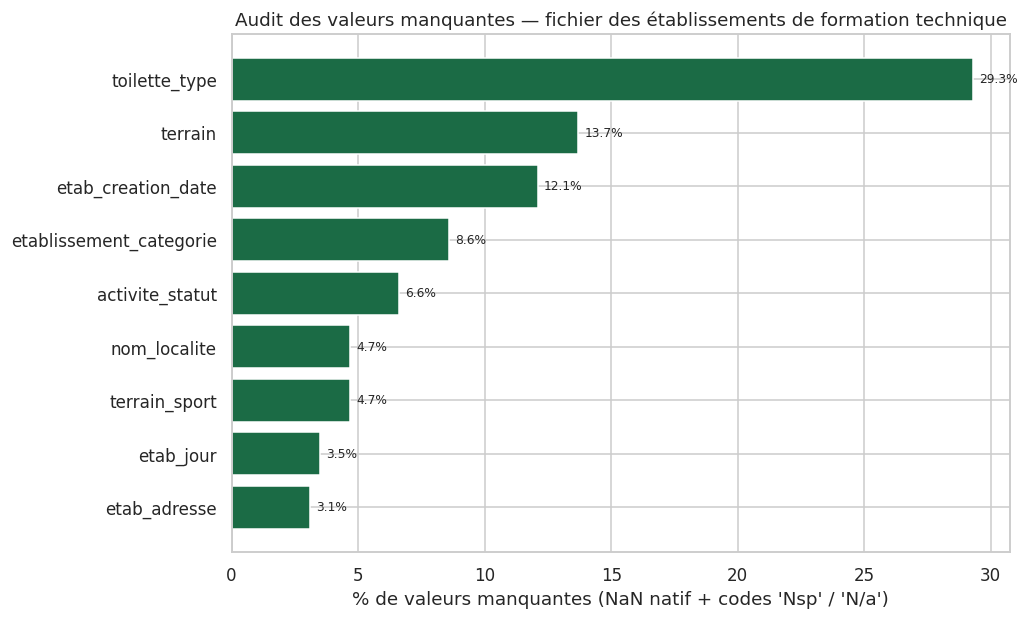

9 colonnes concernées par de la donnée manquante, sur les 16 colonnes du fichier des établissements — les 7 colonnes non listées ci-dessus sont intégralement renseignées (0% manquant), notamment les champs géographiques (région, préfecture, commune) et les coordonnées GPS, qui conditionnent la cartographie de la section 4.


In [8]:

# ------------------------------------------------------------------
# 1.4.a — Audit des données d'enquête (établissements) : NaN natifs + codes de non-réponse
# ------------------------------------------------------------------
NA_TOKENS = {"", "nsp", "n/a", "na", "ne sait pas"}

def audit_missing(df, label, tokens=NA_TOKENS):
    """Quantifie, colonne par colonne, les valeurs manquantes natives (NaN) et les codes
    de non-réponse ('Nsp', 'N/a', chaîne vide, ...) présents dans un DataFrame texte brut."""
    rows = []
    for col in df.columns:
        s = df[col]
        n_native = int(s.isna().sum())
        n_coded = int(s.apply(lambda x: isinstance(x, str) and x.strip().lower() in tokens).sum())
        total = n_native + n_coded
        if total > 0:
            rows.append({
                "jeu_de_données": label, "colonne": col,
                "NaN_natif": n_native, "codes_non_réponse_(Nsp/N-a)": n_coded,
                "total_manquant": total, "% manquant": round(total / len(df) * 100, 1),
            })
    return pd.DataFrame(rows)

audit_all = pd.concat([
    audit_missing(df_etab_raw, "Établissements form. technique (n=256)"),
    audit_missing(df_repart_raw, "Répartition établ. sup. 2018 (n=54)"),
], ignore_index=True).sort_values("% manquant", ascending=False)

display(audit_all.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.5, 5.8))
bar_colors = [PALETTE[0] if "technique" in j else PALETTE[3] for j in audit_all["jeu_de_données"]]
ax.barh(audit_all["colonne"], audit_all["% manquant"], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel("% de valeurs manquantes (NaN natif + codes 'Nsp' / 'N/a')")
ax.set_title("Audit des valeurs manquantes — fichier des établissements de formation technique")
for i, v in enumerate(audit_all["% manquant"]):
    ax.annotate(f"{v}%", (v, i), va="center", fontsize=8, xytext=(4, 0), textcoords="offset points")
plt.tight_layout()
plt.show()

print(f"{len(audit_all)} colonnes concernées par de la donnée manquante, sur les {df_etab_raw.shape[1]} colonnes",
      f"du fichier des établissements — les {df_etab_raw.shape[1] - audit_all[audit_all['jeu_de_données'].str.contains('technique')].shape[0]} colonnes",
      "non listées ci-dessus sont intégralement renseignées (0% manquant), notamment les champs géographiques",
      "(région, préfecture, commune) et les coordonnées GPS, qui conditionnent la cartographie de la section 4.")


In [9]:

# ------------------------------------------------------------------
# 1.4.b — Complétude des séries temporelles nationales
# ------------------------------------------------------------------
def completeness(series, label, period_start=None, period_end=None):
    s = series.dropna()
    start = period_start if period_start is not None else int(s.index.min())
    end = period_end if period_end is not None else int(s.index.max())
    n_years_span = end - start + 1
    return {
        "indicateur": label,
        "1ère année observée": int(s.index.min()),
        "dernière année observée": int(s.index.max()),
        "nb années observées": int(len(s)),
        "années de la période": n_years_span,
        "% couverture de la période": round(len(s) / n_years_span * 100, 1),
    }

ts_completeness = pd.DataFrame([
    completeness(ind_wide["effectifs_etudiants"], "Effectifs étudiants (national)"),
    completeness(ind_wide["ratio_etud_enseignant"], "Ratio étudiant/enseignant (national)"),
    completeness(ind_wide["depense_annuelle_par_etudiant_fcfa"], "Dépense annuelle/étudiant FCFA (national)"),
    completeness(budget_wide["budget_sup_execute"], "Budget enseign. sup. exécuté (national)"),
    completeness(wb_chomage["chomage_diplomes_pct"], "Chômage diplômés (Banque mondiale)", period_start=2006, period_end=2022),
    completeness(wb_depense["depense_etud_pct_pib_hab"], "Dépense/étudiant % PIB/hab (Banque mondiale)"),
    completeness(wb_inscription["taux_brut_inscription_tertiaire"], "Taux brut inscription tertiaire (Banque mondiale)"),
]).sort_values("% couverture de la période")

display(ts_completeness.reset_index(drop=True))

print("Lecture : le chômage des diplômés est, de loin, l'indicateur le plus lacunaire (6 années connues sur 17,",
      "soit 35% de couverture) — c'est précisément la raison pour laquelle la section 11 (Machine Learning)",
      "traite ce point comme une limite structurelle et non comme un simple 'trou à combler'.")


,indicateur,1ère année observée,dernière année observée,nb années observées,années de la période,% couverture de la période
0,Chômage diplômés (Banque mondiale),2006,2022,6,17,35.3
1,Dépense/étudiant % PIB/hab (Banque mondiale),1998,2017,10,20,50.0
2,Dépense annuelle/étudiant FCFA (national),2015,2019,3,5,60.0
3,Ratio étudiant/enseignant (national),2016,2019,3,4,75.0
4,Taux brut inscription tertiaire (Banque mondiale),1971,2020,38,50,76.0
5,Effectifs étudiants (national),2014,2019,5,6,83.3
6,Budget enseign. sup. exécuté (national),2013,2018,6,6,100.0


Lecture : le chômage des diplômés est, de loin, l'indicateur le plus lacunaire (6 années connues sur 17, soit 35% de couverture) — c'est précisément la raison pour laquelle la section 11 (Machine Learning) traite ce point comme une limite structurelle et non comme un simple 'trou à combler'.


### 1.5 Règles de traitement retenues

- **Champs géographiques** (région, GPS) : 0% manquant → aucun traitement.
- **Champs qualitatifs déclaratifs** (toilettes, terrain, catégorie...) : **jamais imputés** — exclus au cas par cas via `dropna`, uniquement dans les analyses qui utilisent le champ concerné.
- **Filière/spécialité absente** : remplacée par une estimation par mots-clés (`secteur_estime`), toujours signalée ⚠️.
- **Séries nationales annuelles** : jamais imputées dans les analyses descriptives — seules les années réellement observées sont tracées.
- **Prédicteurs du modèle ML uniquement** : interpolation linéaire entre années observées, avec un marqueur `__observe` explicite ; la cible (chômage) n'est **jamais** interpolée.
- **Budget régionalisé absent** : aucune ventilation fabriquée — valeur nationale appliquée uniformément aux régions, signalée ⚠️.

> 🧭 Une valeur manquante est donc **exclue avec traçabilité**, **interpolée avec marqueur**, ou **remplacée par une estimation signalée** — jamais comblée silencieusement.


<a id="2"></a>
## 2. Note méthodologique — portée et limites des données

> 📋 Détail chiffré des valeurs manquantes : sections **1.4** et **1.5** ci-dessus.

### 2.1 Ce que les données permettent de faire directement

| Analyse | Granularité réelle |
|---|---|
| Cartographie des formations techniques | Établissement géolocalisé, 256 structures, 5 régions |
| Public/privé, université/établissement | Ville, année 2018 |
| Effectifs, féminisation, ratio étudiant/enseignant | National, annuel, 2014-2019 |
| Budgets (voté/exécuté), PIB | National, annuel, 2013-2018 |
| Chômage des diplômés, dépense/étudiant, inscription | Banque mondiale, national, très lacunaire |

### 2.2 Ce que les données ne permettent pas — et comment ce notebook compense

- ❌ **Pas de filière détaillée** → estimée par mots-clés (`secteur_estime` ⚠️).
- ❌ **Pas de budget régionalisé** → valeur nationale appliquée uniformément aux régions (⚠️, section 13).
- ❌ **Pas de chômage par filière/région** → modèle ML (section 11) traité comme exploratoire, jamais prédictif.
- ❌ **Pas de table formation ↔ emploi** → graphe construit sur Formation/Catégorie ↔ Secteur estimé ↔ Région.
- ⚠️ **Chevauchement temporel limité** entre budgets, indicateurs et chômage → corrélations indicatives, non causales.

### 2.3 Enrichissement externe

Populations régionales du **RGPH-5 (INSEED, novembre 2022)** — seule donnée externe injectée, pour normaliser la couverture territoriale.

> 🧭 **Principe directeur** : tout graphique ou score construit à partir d'une estimation, d'une valeur nationale appliquée uniformément, ou d'une heuristique porte le symbole **⚠️**. Son absence signifie une donnée directement observée.


In [10]:

# Population régionale — RGPH-5 (INSEED Togo, résultats définitifs, nov. 2022)
# Source : Institut National de la Statistique et des Études Économiques et Démographiques (INSEED),
# repris par l'Agence Togolaise de Presse (ATOP), avril 2023.
POPULATION_REGION_2022 = {
    "Maritime": 3_534_991,   # dont Grand Lomé : 2 188 376
    "Plateaux": 1_635_946,
    "Savanes": 1_143_520,
    "Kara": 985_512,
    "Centrale": 795_529,
}
pop_df = pd.Series(POPULATION_REGION_2022, name="population_2022").rename_axis("region").reset_index()
pop_df["population_2022_M"] = (pop_df["population_2022"] / 1_000_000).round(2)
display(pop_df)
print(f"Population totale du Togo (RGPH-5, 2022) : {sum(POPULATION_REGION_2022.values()):,} habitants".replace(",", " "))


,region,population_2022,population_2022_M
0,Maritime,3534991,3.53
1,Plateaux,1635946,1.64
2,Savanes,1143520,1.14
3,Kara,985512,0.99
4,Centrale,795529,0.80


Population totale du Togo (RGPH-5  2022) : 8 095 498 habitants


---
## Partie II — Diagnostic complet
*(sections 3 à 15 : offre, effectifs, budgets, chômage, théorie des graphes, Machine Learning, indicateurs composites)*

<a id="3"></a>
## 3. Indicateurs clés (KPI) globaux

Calcul automatique des indicateurs de cadrage demandés dans le cahier des charges, à partir des données
directement observées.


In [11]:

kpi = {}
kpi["Nombre de formations techniques recensées"] = len(df_etab)
kpi["Nombre de régions couvertes (formation technique)"] = df_etab["region_nom_bdd"].nunique()
kpi["Nombre de préfectures couvertes"] = df_etab["prefecture_nom_bdd"].nunique()
kpi["Nombre d'établissements sup. recensés (2018)"] = int(df_repart[df_repart["type"] == "Etablissement"]["Value"].sum())
kpi["Nombre d'universités recensées (2018)"] = int(df_repart[df_repart["type"] == "Université"]["Value"].sum())
kpi["Taux de féminisation le plus récent (%)"] = round(ind_wide["taux_feminisation"].dropna().iloc[-1], 1)
kpi["Ratio étudiants/enseignants le plus récent"] = round(ind_wide["ratio_etud_enseignant"].dropna().iloc[-1], 1)
kpi["Dépense annuelle/étudiant la plus récente (FCFA)"] = f"{int(ind_wide['depense_annuelle_par_etudiant_fcfa'].dropna().iloc[-1]):,}".replace(",", " ")
kpi["Part des filières scientifiques la plus récente (%)"] = round(ind_wide["pct_filieres_scientifiques"].dropna().iloc[-1], 1)
kpi["Taux d'exécution budgétaire sup. moyen (%)"] = round(budget_wide["taux_execution_sup"].mean(), 1)
kpi["Chômage diplômés le plus récent connu (%, année)"] = (
    f"{wb_chomage['chomage_diplomes_pct'].iloc[-1]:.1f}% ({wb_chomage.index[-1]})"
)

kpi_df = pd.DataFrame(list(kpi.items()), columns=["Indicateur", "Valeur"])
display(kpi_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))


Indicateur,Valeur
Nombre de formations techniques recensées,256
Nombre de régions couvertes (formation technique),5
Nombre de préfectures couvertes,32
Nombre d'établissements sup. recensés (2018),69
Nombre d'universités recensées (2018),4
Taux de féminisation le plus récent (%),51.500000
Ratio étudiants/enseignants le plus récent,91.000000
Dépense annuelle/étudiant la plus récente (FCFA),354 110
Part des filières scientifiques la plus récente (%),23.600000
Taux d'exécution budgétaire sup. moyen (%),92.900000


In [12]:

# Visualisation "cartes KPI" façon tableau de bord
fig = make_subplots(
    rows=2, cols=4,
    specs=[[{"type": "indicator"}] * 4, [{"type": "indicator"}] * 4],
    horizontal_spacing=0.05, vertical_spacing=0.35,
)

indicators = [
    ("Formations techniques", kpi["Nombre de formations techniques recensées"], ""),
    ("Régions couvertes", kpi["Nombre de régions couvertes (formation technique)"], "/5"),
    ("Préfectures couvertes", kpi["Nombre de préfectures couvertes"], "/39"),
    ("Universités (2018)", kpi["Nombre d'universités recensées (2018)"], ""),
    ("Féminisation étudiants", kpi["Taux de féminisation le plus récent (%)"], "%"),
    ("Ratio étud./enseignant", kpi["Ratio étudiants/enseignants le plus récent"], ":1"),
    ("Filières scientifiques", kpi["Part des filières scientifiques la plus récente (%)"], "%"),
    ("Exéc. budgétaire sup.", kpi["Taux d'exécution budgétaire sup. moyen (%)"], "%"),
]

for i, (label, value, suffix) in enumerate(indicators):
    r, c = divmod(i, 4)
    fig.add_trace(go.Indicator(
        mode="number",
        value=value if isinstance(value, (int, float)) else 0,
        number={"suffix": suffix, "font": {"size": 34, "color": PALETTE[i % len(PALETTE)]}},
        title={"text": label, "font": {"size": 13}},
    ), row=r + 1, col=c + 1)

fig.update_layout(height=380, margin=dict(t=40, b=10, l=10, r=10),
                   title="Tableau de bord synthétique — indicateurs clés", title_x=0.5)
fig.show()


<a id="4"></a>
## 4. Cartographie de l'offre de formations techniques par région

### 4.1 Répartition régionale — régions bien couvertes vs sous-dotées


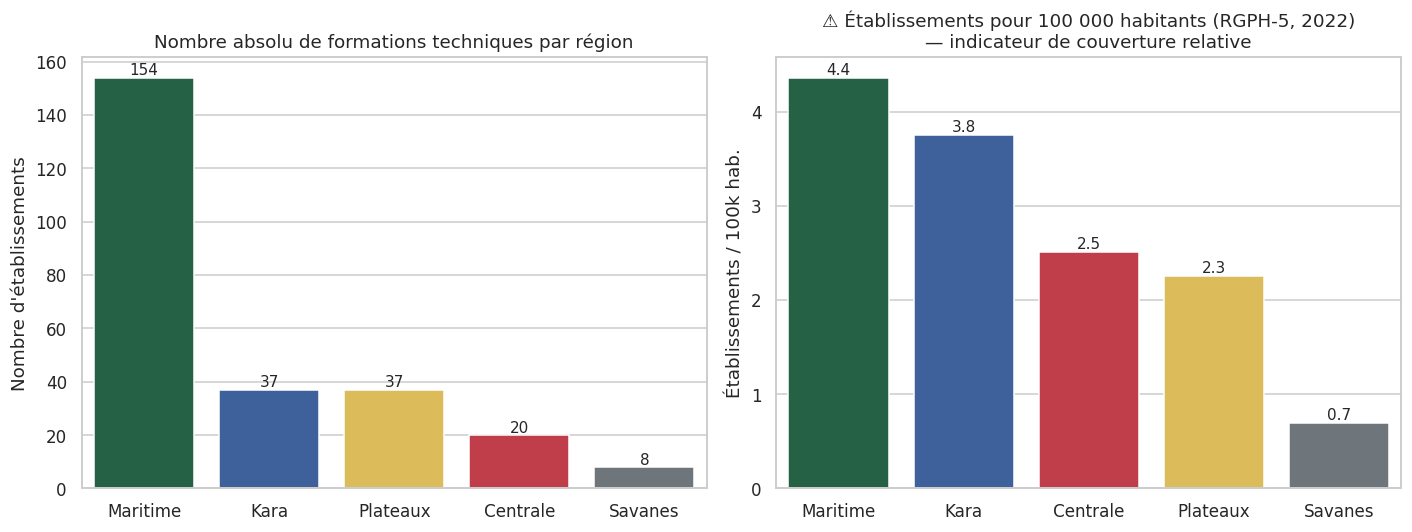

Lecture :
 - Région la mieux dotée en absolu : Maritime (154 établissements)
 - Région la mieux dotée rapportée à la population : Maritime
 - Région la plus sous-dotée rapportée à la population : Savanes


In [13]:
region_counts = df_etab["region_nom_bdd"].value_counts().reindex(REGIONS).fillna(0).astype(int)
cover_df = region_counts.rename("nb_etablissements").reset_index().rename(columns={"region_nom_bdd": "region"})
cover_df = cover_df.merge(pop_df, on="region")
cover_df["etab_pour_100k_hab"] = (cover_df["nb_etablissements"] / cover_df["population_2022"] * 100_000).round(2)
cover_df = cover_df.sort_values("etab_pour_100k_hab", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order1 = cover_df.sort_values("nb_etablissements", ascending=False)["region"]
sns.barplot(data=cover_df, x="region", y="nb_etablissements", order=order1,
            palette=[REGION_COLORS[r] for r in order1], ax=axes[0])
axes[0].set_title("Nombre absolu de formations techniques par région")
axes[0].set_xlabel(""); axes[0].set_ylabel("Nombre d'établissements")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontsize=10)

order2 = cover_df["region"]
sns.barplot(data=cover_df, x="region", y="etab_pour_100k_hab", order=order2,
            palette=[REGION_COLORS[r] for r in order2], ax=axes[1])
axes[1].set_title("⚠️ Établissements pour 100 000 habitants (RGPH-5, 2022)\n— indicateur de couverture relative")
axes[1].set_xlabel(""); axes[1].set_ylabel("Établissements / 100k hab.")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print("Lecture :")
print(f" - Région la mieux dotée en absolu : {order1.iloc[0]} ({cover_df.set_index('region').loc[order1.iloc[0], 'nb_etablissements']} établissements)")
print(f" - Région la mieux dotée rapportée à la population : {order2.iloc[0]}")
print(f" - Région la plus sous-dotée rapportée à la population : {order2.iloc[-1]}")

### 4.2 Carte interactive des établissements de formation technique

In [14]:

geo = df_etab.dropna(subset=["lat", "lon"]).copy()

fig = px.scatter_mapbox(
    geo, lat="lat", lon="lon",
    color="region_nom_bdd",
    color_discrete_map=REGION_COLORS,
    hover_name="etab_nom",
    hover_data={"prefecture_nom_bdd": True, "etablissement_categorie": True, "secteur_estime": True,
                "lat": False, "lon": False},
    zoom=6.2, height=580,
    title="Localisation des établissements de formation technique — Togo",
)
fig.update_layout(mapbox_style="carto-positron", margin=dict(t=45, b=0, l=0, r=0),
                   legend_title_text="Région")
fig.show()


### 4.3 Spécialités disponibles ⚠️ (estimation heuristique par mots-clés)

> ⚠️ Le champ *spécialité* n'existe pas dans l'extraction fournie. Le secteur ci-dessous est **déduit du nom de
> l'établissement** par détection de mots-clés (cf. §2.2). Une large part des établissements reste **« non
> identifiée »** faute d'indice textuel suffisant — c'est un résultat honnête, pas une lacune du code.


In [15]:

sector_region = pd.crosstab(df_etab["region_nom_bdd"], df_etab["secteur_estime"])
sector_region = sector_region.reindex(REGIONS)

fig = px.imshow(
    sector_region.T, text_auto=True, aspect="auto",
    color_continuous_scale="YlGnBu",
    labels=dict(x="Région", y="Secteur estimé ⚠️", color="Nb établissements"),
    title="⚠️ Secteurs estimés des formations techniques par région (heuristique par mots-clés)",
)
fig.update_layout(height=480, margin=dict(t=60, b=10))
fig.show()

sector_share = df_etab["secteur_estime"].value_counts(normalize=True).mul(100).round(1)
print("Part des établissements par secteur estimé (Togo entier) :")
display(sector_share.rename("part (%)"))


Part des établissements par secteur estimé (Togo entier) :


secteur_estime
Non identifié                           78.9
Polytechnique / Multi-filières           7.4
Hôtellerie / Restauration / Tourisme     3.5
Couture / Textile / Mode                 2.7
Informatique / Numérique                 2.3
Agriculture / Agro-industrie             2.0
Commerce / Gestion / Banque              1.6
Bâtiment / BTP                           1.2
Santé / Social                           0.4
Name: part (%), dtype: float64

### 4.4 Catégories de diplôme délivré, par région (donnée réelle)

In [16]:

cat_region = pd.crosstab(df_etab["region_nom_bdd"], df_etab["etablissement_categorie"].fillna("Non renseigné"))
cat_region = cat_region.reindex(REGIONS)

fig = px.bar(
    cat_region.reset_index().melt(id_vars="region_nom_bdd", var_name="categorie", value_name="nb"),
    x="region_nom_bdd", y="nb", color="categorie", barmode="stack",
    category_orders={"region_nom_bdd": REGIONS},
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Répartition des catégories de formation technique par région",
    labels={"region_nom_bdd": "Région", "nb": "Nombre d'établissements", "categorie": "Catégorie"},
)
fig.update_layout(height=470, margin=dict(t=60, b=10))
fig.show()


### 4.5 Dynamique de création des établissements (donnée réelle)

Le champ `etab_creation_date` permet de retracer l'ouverture des établissements dans le temps (225 établissements
sur 256 renseignent une année exploitable).


In [17]:

creation = df_etab.dropna(subset=["annee_creation"]).copy()
creation["decennie"] = (creation["annee_creation"] // 10 * 10).astype(int)
decade_counts = creation.groupby(["decennie", "region_nom_bdd"]).size().unstack(fill_value=0).reindex(columns=REGIONS, fill_value=0)

fig = px.area(
    decade_counts.reset_index().melt(id_vars="decennie", var_name="region", value_name="nb"),
    x="decennie", y="nb", color="region",
    color_discrete_map=REGION_COLORS,
    title="Créations d'établissements de formation technique par décennie et par région",
    labels={"decennie": "Décennie de création", "nb": "Nombre d'établissements créés"},
)
fig.update_layout(height=450, margin=dict(t=60, b=10))
fig.show()

print(f"{(creation['annee_creation'] >= 2010).sum()} établissements sur {len(creation)} ont été créés depuis 2010",
      f"({(creation['annee_creation'] >= 2010).mean()*100:.0f}% du parc daté) — signe d'une expansion récente de l'offre.")


113 établissements sur 225 ont été créés depuis 2010 (50% du parc daté) — signe d'une expansion récente de l'offre.


<a id="5"></a>
## 5. Enseignement supérieur : effectifs, féminisation, filières scientifiques

Données réelles, nationales, annuelles (2014-2019 selon l'indicateur).


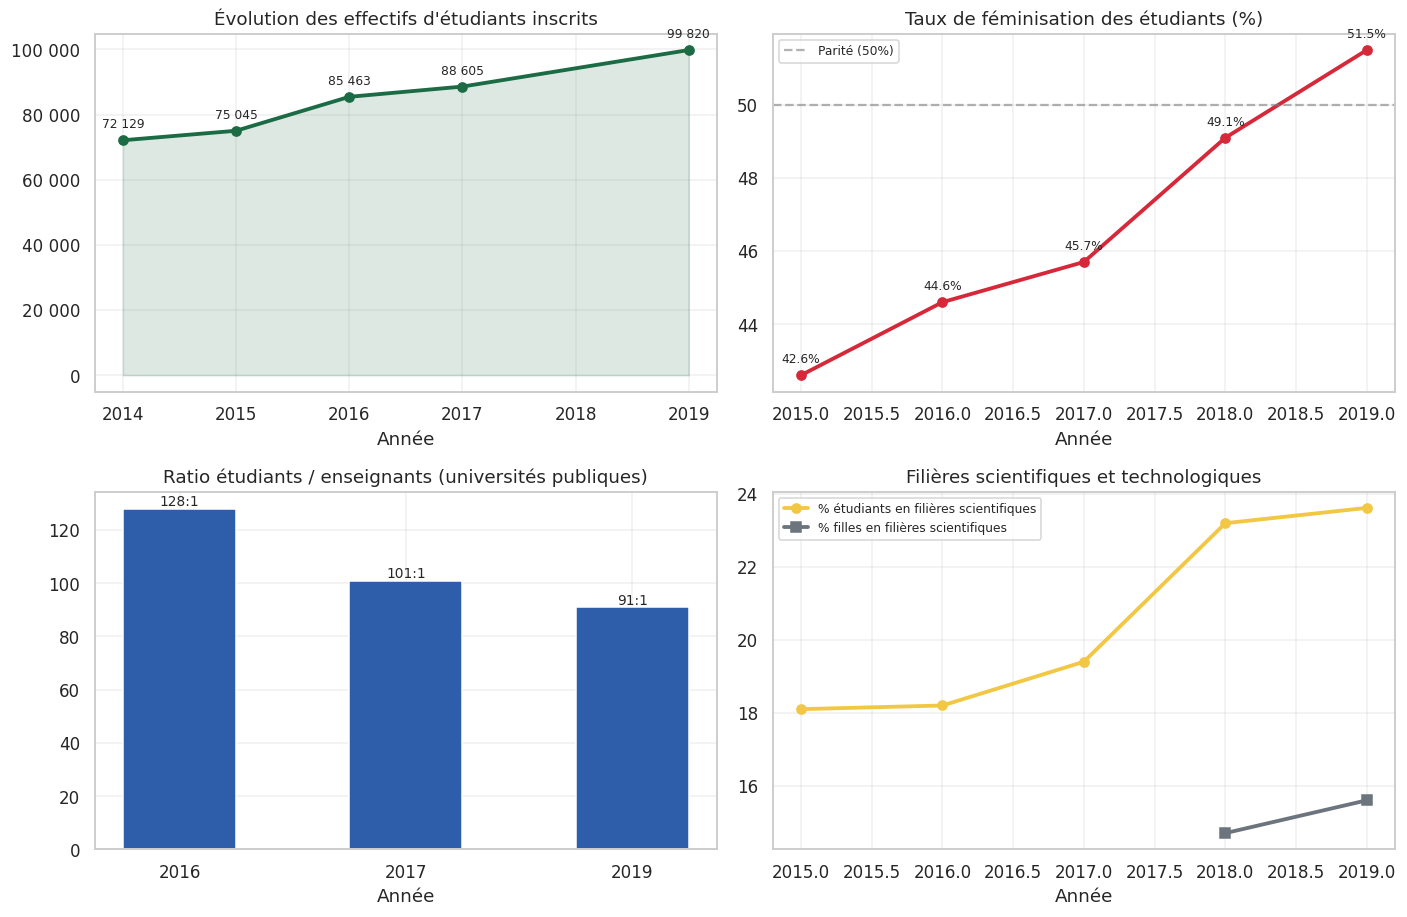

In [18]:

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

# Effectifs
ax = axes[0, 0]
s = ind_wide["effectifs_etudiants"].dropna()
ax.plot(s.index, s.values, marker="o", color=PALETTE[0], linewidth=2.5)
ax.fill_between(s.index, s.values, color=PALETTE[0], alpha=0.15)
ax.set_title("Évolution des effectifs d'étudiants inscrits")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))
for x, y in zip(s.index, s.values):
    ax.annotate(f"{int(y):,}".replace(",", " "), (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")

# Féminisation
ax = axes[0, 1]
s = ind_wide["taux_feminisation"].dropna()
ax.plot(s.index, s.values, marker="o", color=PALETTE[2], linewidth=2.5)
ax.axhline(50, ls="--", color="gray", alpha=0.6, label="Parité (50%)")
ax.set_title("Taux de féminisation des étudiants (%)")
ax.legend(fontsize=8)
for x, y in zip(s.index, s.values):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")

# Ratio étudiant/enseignant
ax = axes[1, 0]
s = ind_wide["ratio_etud_enseignant"].dropna()
ax.bar(s.index.astype(str), s.values, color=PALETTE[3], width=0.5)
ax.set_title("Ratio étudiants / enseignants (universités publiques)")
for x, y in zip(range(len(s)), s.values):
    ax.annotate(f"{y:.0f}:1", (x, y), ha="center", va="bottom", fontsize=9)

# Filières scientifiques
ax = axes[1, 1]
s1 = ind_wide["pct_filieres_scientifiques"].dropna()
s2 = ind_wide["pct_filles_filieres_sci"].dropna()
ax.plot(s1.index, s1.values, marker="o", label="% étudiants en filières scientifiques", color=PALETTE[1], linewidth=2.5)
ax.plot(s2.index, s2.values, marker="s", label="% filles en filières scientifiques", color=PALETTE[4], linewidth=2.5)
ax.set_title("Filières scientifiques et technologiques")
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel("Année")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Lecture :** les effectifs et la féminisation progressent de façon continue sur la période observée, tandis
que le ratio étudiants/enseignants **se détend** (128 → 91 entre 2016 et 2019), signe d'un effort d'encadrement.
La part des filières scientifiques progresse (18,1 % → 23,6 %) mais reste **minoritaire**, et la féminisation de
ces filières spécifiquement (14,7 % → 15,6 %) demeure **très inférieure** à la féminisation globale — un point
d'attention pour les politiques d'orientation.


<a id="6"></a>
## 6. Établissements d'enseignement supérieur — public vs privé (donnée réelle, 2018)


In [19]:

pub_priv = df_repart.groupby(["type", "statut"])["Value"].sum().unstack(fill_value=0)
display(pub_priv)

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "domain"}, {"type": "xy"}]],
                     subplot_titles=("Répartition Public / Privé (tous établissements)",
                                      "Établissements par ville, statut et type"))

totals_statut = df_repart.groupby("statut")["Value"].sum()
fig.add_trace(go.Pie(labels=totals_statut.index, values=totals_statut.values,
                      marker_colors=[PALETTE[0], PALETTE[2]], hole=0.45,
                      textinfo="label+percent"), row=1, col=1)

city_type_statut = df_repart.groupby(["villes", "type", "statut"])["Value"].sum().reset_index()
city_type_statut["label"] = city_type_statut["type"] + " " + city_type_statut["statut"]
for i, lab in enumerate(city_type_statut["label"].unique()):
    d = city_type_statut[city_type_statut["label"] == lab]
    fig.add_trace(go.Bar(x=d["villes"], y=d["Value"], name=lab,
                          marker_color=px.colors.qualitative.Set2[i % 8]), row=1, col=2)

fig.update_layout(barmode="stack", height=470, margin=dict(t=60, b=10),
                   title_text="Établissements d'enseignement supérieur ayant fonctionné (2018)")
fig.show()

print(f"Sur {int(df_repart['Value'].sum())} structures recensées en 2018, "
      f"{totals_statut.get('Prive', 0) / totals_statut.sum() * 100:.0f}% relèvent du secteur privé — "
      f"Lomé concentre à elle seule {int(city_type_statut[city_type_statut['villes']=='LOMÉ']['Value'].sum())} structures.")


statut,Prive,Public
type,,
Etablissement,65,4
Université,2,2


Sur 73 structures recensées en 2018, 92% relèvent du secteur privé — Lomé concentre à elle seule 57 structures.


### 6.1 Sunburst — hiérarchie Région → Ville → Type → Statut

In [20]:

sb = df_repart.copy()
sb["region"] = sb["region"].fillna("Autre")
fig = px.sunburst(
    sb, path=["region", "villes", "type", "statut"], values="Value",
    color="region", color_discrete_map=REGION_COLORS,
    title="Établissements d'enseignement supérieur — Région → Ville → Type → Statut (2018)",
)
fig.update_layout(height=560, margin=dict(t=60, b=10))
fig.show()


<a id="7"></a>
## 7. Évolution des inscriptions et projections simples

Le taux brut d'inscription dans le supérieur (Banque mondiale) offre la **plus longue série disponible**
(1971-2020), ce qui permet une analyse de tendance robuste.


In [21]:

s = wb_inscription["taux_brut_inscription_tertiaire"].dropna().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(x=s.index, y=s.values, mode="lines+markers", name="Taux brut d'inscription (%)",
                          line=dict(color=PALETTE[0], width=3)))

# Régression linéaire simple sur les 15 dernières années observées pour une projection à horizon 2030
recent = s[s.index >= s.index.max() - 15]
X = recent.index.values.reshape(-1, 1).astype(float)
y = recent.values
reg = LinearRegression().fit(X, y)
future_years = np.arange(s.index.max() + 1, 2031)
future_pred = reg.predict(future_years.reshape(-1, 1))
future_pred = np.clip(future_pred, 0, None)

fig.add_trace(go.Scatter(x=future_years, y=future_pred, mode="lines+markers",
                          name="⚠️ Projection linéaire naïve (tendance récente)",
                          line=dict(color=PALETTE[2], width=2, dash="dash")))

fig.update_layout(title="Évolution du taux brut d'inscription dans le supérieur (%) — 1971-2020, projection ⚠️ à 2030",
                   xaxis_title="Année", yaxis_title="Taux brut d'inscription (%)",
                   height=470, margin=dict(t=60, b=10))
fig.show()

print(f"Croissance moyenne annuelle sur les 15 dernières années observées : {reg.coef_[0]:.2f} points/an.")
print(f"⚠️ Projection 2030 (tendance linéaire naïve, à ne pas sur-interpréter) : {future_pred[-1]:.1f}%")


Croissance moyenne annuelle sur les 15 dernières années observées : 0.63 points/an.
⚠️ Projection 2030 (tendance linéaire naïve, à ne pas sur-interpréter) : 21.0%


> ⚠️ Cette projection est une **simple extrapolation linéaire** de la tendance récente, fournie à titre
> illustratif. Elle ne tient compte d'aucun choc économique, démographique ou de politique publique et ne doit
> pas être utilisée comme une prévision officielle.


<a id="8"></a>
## 8. Budgets de l'enseignement supérieur

### 8.1 Budget voté vs exécuté, et poids dans le budget national


In [22]:

fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "Budget de l'enseignement supérieur — Voté vs Exécuté (millions FCFA)",
    "Taux d'exécution budgétaire (%)"))

fig.add_trace(go.Bar(x=budget_wide.index.astype(str), y=budget_wide["budget_sup_vote"],
                      name="Voté", marker_color=PALETTE[3]), row=1, col=1)
fig.add_trace(go.Bar(x=budget_wide.index.astype(str), y=budget_wide["budget_sup_execute"],
                      name="Exécuté", marker_color=PALETTE[0]), row=1, col=1)

fig.add_trace(go.Scatter(x=budget_wide.index.astype(str), y=budget_wide["taux_execution_sup"],
                          mode="lines+markers", name="Taux d'exécution", line=dict(color=PALETTE[2], width=3)),
              row=1, col=2)
fig.add_hline(y=100, line_dash="dash", line_color="gray", row=1, col=2)

fig.update_layout(barmode="group", height=430, margin=dict(t=60, b=10),
                   title_text="Exécution budgétaire de l'enseignement supérieur (2013-2018)")
fig.show()

print(f"Taux d'exécution moyen 2013-2018 : {budget_wide['taux_execution_sup'].mean():.1f}%",
      "— l'exécution est globalement proche ou supérieure au budget voté, signe d'un financement additionnel en cours d'année"
      if budget_wide['taux_execution_sup'].mean() > 95 else "— une part du budget voté n'est pas consommée.")


Taux d'exécution moyen 2013-2018 : 92.9% — une part du budget voté n'est pas consommée.


In [23]:

budget_wide["part_sup_dans_education"] = (budget_wide["budget_education_execute"].replace(0, np.nan))
share_df = pd.DataFrame({
    "Budget enseign. sup.": budget_wide["budget_sup_execute"],
    "Budget éducation (hors sup.)": (budget_wide["budget_education_execute"] - budget_wide["budget_sup_execute"]).clip(lower=0),
    "Reste du budget national": (budget_wide["budget_national_execute"] - budget_wide["budget_education_execute"]).clip(lower=0),
})

fig = px.area(
    share_df.reset_index().melt(id_vars="Date", var_name="Poste", value_name="Montant"),
    x="Date", y="Montant", color="Poste",
    color_discrete_sequence=[PALETTE[0], PALETTE[1], PALETTE[4]],
    title="Décomposition du budget national exécuté (millions FCFA)",
    labels={"Date": "Année", "Montant": "Montant (millions FCFA)"},
)
fig.update_layout(height=440, margin=dict(t=60, b=10))
fig.show()

pct_sup = (budget_wide["budget_sup_execute"] / budget_wide["budget_national_execute"] * 100).mean()
print(f"L'enseignement supérieur représente en moyenne {pct_sup:.2f}% du budget national exécuté (2013-2018).")


L'enseignement supérieur représente en moyenne 4.05% du budget national exécuté (2013-2018).


### 8.2 Dépense publique par étudiant

Deux sources se complètent : la dépense annuelle en FCFA (nationale, 2015-2019) et la dépense en % du PIB par
habitant (Banque mondiale, plus ancienne mais internationalement comparable).


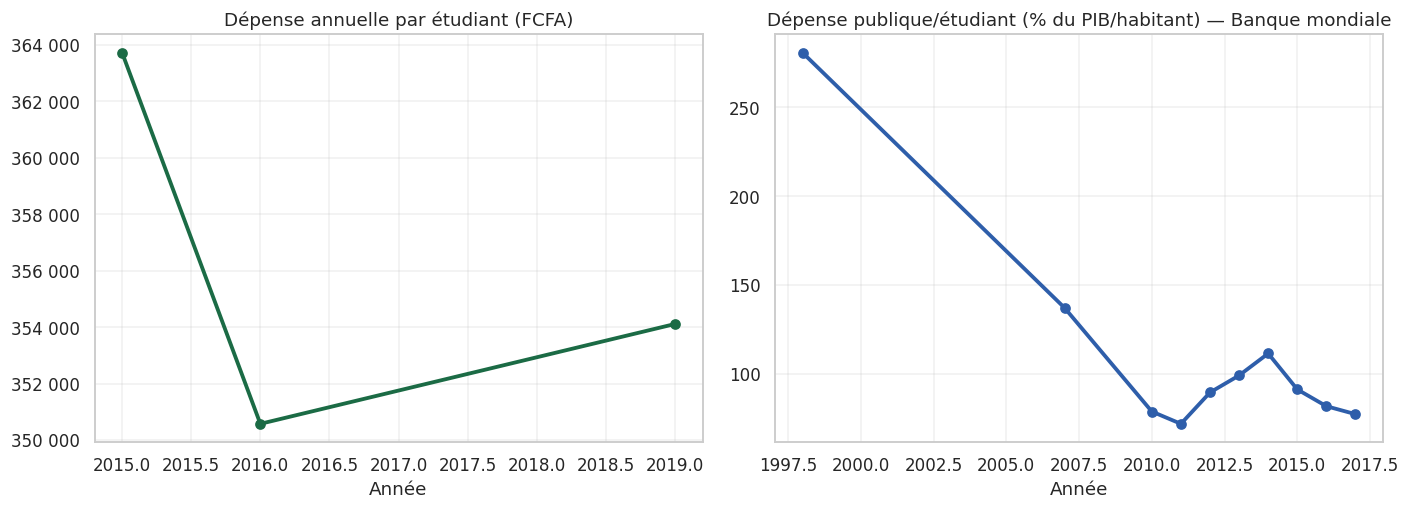

Tendance : la dépense par étudiant en % du PIB/habitant a fortement décru depuis 1998 (280,7% -> ~77-90% entre 2010 et 2017), ce qui traduit une croissance des effectifs plus rapide que celle du financement par tête.


In [24]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

s = ind_wide["depense_annuelle_par_etudiant_fcfa"].dropna()
axes[0].plot(s.index, s.values, marker="o", color=PALETTE[0], linewidth=2.5)
axes[0].set_title("Dépense annuelle par étudiant (FCFA)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))

s2 = wb_depense["depense_etud_pct_pib_hab"].dropna().sort_index()
axes[1].plot(s2.index, s2.values, marker="o", color=PALETTE[3], linewidth=2.5)
axes[1].set_title("Dépense publique/étudiant (% du PIB/habitant) — Banque mondiale")

for ax in axes:
    ax.set_xlabel("Année"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Tendance : la dépense par étudiant en % du PIB/habitant a fortement décru depuis 1998 (280,7% -> ~77-90%",
      "entre 2010 et 2017), ce qui traduit une croissance des effectifs plus rapide que celle du financement par tête.")


### 8.3 Chaîne Budget → Qualité de l'encadrement → Insertion / Chômage

> ⚠️ Les années disponibles pour le budget (2013-2018), l'encadrement (2016-2019) et le chômage (années
> éparses) se recoupent sur très peu de points communs. Le graphique ci-dessous **visualise la chaîne
> conceptuelle** demandée par le cahier des charges ; la lecture doit rester **qualitative**, pas statistique.


In [25]:

chain = national[["depense_annuelle_par_etudiant_fcfa", "ratio_etud_enseignant",
                   "taux_inscription_immediat_bac", "chomage_diplomes_pct"]].dropna(how="all")
display(chain)

fig = go.Figure()
for i, col in enumerate(chain.columns):
    s = chain[col].dropna()
    fig.add_trace(go.Scatter(x=s.index, y=(s - s.min()) / (s.max() - s.min()) * 100,
                              mode="lines+markers", name=col, line=dict(color=PALETTE[i % len(PALETTE)])))
fig.update_layout(title="⚠️ Chaîne Budget → Encadrement → Insertion → Chômage (indices normalisés 0-100, lecture qualitative)",
                   xaxis_title="Année", yaxis_title="Indice normalisé (0=min, 100=max sur la période observée)",
                   height=460, margin=dict(t=60, b=10))
fig.show()


,depense_annuelle_par_etudiant_fcfa,ratio_etud_enseignant,taux_inscription_immediat_bac,chomage_diplomes_pct
annee,,,,
2006,NaN,NaN,NaN,11.678
2011,NaN,NaN,NaN,6.952
2015,363725.14,NaN,NaN,8.227
2016,350571.10,128.0,39.00,NaN
2017,NaN,101.0,55.90,13.489
2019,354110.00,91.0,58.24,12.622
2022,NaN,NaN,NaN,7.068


<a id="9"></a>
## 9. Chômage des diplômés

### 9.1 Évolution nationale (donnée réelle, mais lacunaire)


In [26]:

s = wb_chomage["chomage_diplomes_pct"].dropna().sort_index()
fig = go.Figure()
fig.add_trace(go.Scatter(x=s.index, y=s.values, mode="lines+markers",
                          line=dict(color=PALETTE[2], width=3), marker=dict(size=10),
                          name="Chômage des diplômés du supérieur (%)"))
fig.update_layout(title="Taux de chômage des diplômés de l'enseignement supérieur — Togo (Banque mondiale)",
                   xaxis_title="Année", yaxis_title="% de la population active diplômée du supérieur",
                   height=430, margin=dict(t=60, b=10))
fig.show()

print("Années disponibles :", list(s.index))
print(f"Le taux oscille entre {s.min():.1f}% ({s.idxmin()}) et {s.max():.1f}% ({s.idxmax()}), sans tendance linéaire nette",
      "— la série est trop courte et trop irrégulière pour conclure à une amélioration ou une dégradation structurelle.")


Années disponibles : [np.int64(2006), np.int64(2011), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2022)]
Le taux oscille entre 7.0% (2011) et 13.5% (2017), sans tendance linéaire nette — la série est trop courte et trop irrégulière pour conclure à une amélioration ou une dégradation structurelle.


### 9.2 Formations « saturées » vs « porteuses » ⚠️ (indice de risque proxy)

> ⚠️ **Limite majeure documentée en §2** : aucune donnée ne relie le chômage à une filière, un diplôme ou une
> région précise. Le cahier des charges demande néanmoins d'« identifier les formations saturées / porteuses ».
> Nous construisons donc un **indice de risque de saturation ⚠️** purement **structurel** (et non basé sur une
> mesure réelle du chômage par filière), défini pour chaque catégorie de formation comme :
>
> `indice_saturation = (poids relatif de la catégorie dans l'offre actuelle) × (part des créations récentes
> dans cette catégorie, depuis 2010)`
>
> Une catégorie qui pèse déjà lourd dans l'offre **et** qui continue de s'étendre rapidement est considérée à
> risque de saturation ; une catégorie rare et en expansion est jugée porteuse. **Ceci reste une hypothèse de
> travail à confronter à une véritable enquête d'insertion des diplômés.**


In [27]:

cat_data = df_etab.dropna(subset=["etablissement_categorie"]).copy()
poids = cat_data["etablissement_categorie"].value_counts(normalize=True)
recent_share = cat_data.assign(recent=cat_data["annee_creation"] >= 2010).groupby("etablissement_categorie")["recent"].mean()

risk = pd.DataFrame({"poids_dans_offre": poids, "part_creations_recentes": recent_share}).dropna()
risk["indice_saturation_proxy"] = (risk["poids_dans_offre"] * risk["part_creations_recentes"] * 100).round(1)
risk = risk.sort_values("indice_saturation_proxy", ascending=False)
display(risk)

fig = px.bar(risk.reset_index(), x="etablissement_categorie", y="indice_saturation_proxy",
             color="indice_saturation_proxy", color_continuous_scale="RdYlGn_r",
             title="⚠️ Indice de saturation proxy par catégorie de formation (heuristique, non validé empiriquement)",
             labels={"etablissement_categorie": "Catégorie", "indice_saturation_proxy": "Indice (0-100)"})
fig.update_layout(height=430, margin=dict(t=60, b=10))
fig.show()

print(f"Catégorie la plus exposée au risque de saturation (proxy) : {risk.index[0]}")
print(f"Catégorie jugée la plus porteuse (proxy) : {risk.index[-1]}")


,poids_dans_offre,part_creations_recentes,indice_saturation_proxy
etablissement_categorie,,,
Formation Professionnelle autre,0.816239,0.460733,37.6
CAP,0.158120,0.513514,8.1
BTS,0.017094,0.250000,0.4
Licence,0.008547,0.500000,0.4


Catégorie la plus exposée au risque de saturation (proxy) : Formation Professionnelle autre
Catégorie jugée la plus porteuse (proxy) : Licence


<a id="10"></a>
## 10. Théorie des graphes — structure du système Formation ↔ Territoire ↔ Emploi

C'est la **valeur ajoutée distinctive** de ce notebook : au-delà des statistiques descriptives, la théorie des
graphes révèle la **structure relationnelle** du système éducatif togolais — quelles régions sont des pivots,
quelles catégories de formation dominent, où se logent les points de fragilité.

> ⚠️ Comme documenté en §2, aucune table ne relie formations, secteurs d'emploi réels et diplômés. Les graphes
> « Formation ↔ Emploi » et « Budget ↔ Région » du cahier des charges sont donc reconstruits ici à partir des
> **variables disponibles les plus proches** (catégorie de formation, secteur estimé, région, ville, statut),
> ce qui est signalé à chaque graphe concerné.

### 10.1 Graphe bipartite Région ↔ Catégorie de formation


In [28]:

G1 = nx.Graph()

for r in REGIONS:
    G1.add_node(r, bipartite=0, kind="region")

categories = df_etab["etablissement_categorie"].dropna().unique()
for c in categories:
    G1.add_node(c, bipartite=1, kind="categorie")

edge_weights = df_etab.dropna(subset=["etablissement_categorie"]).groupby(
    ["region_nom_bdd", "etablissement_categorie"]).size()
for (r, c), w in edge_weights.items():
    G1.add_edge(r, c, weight=int(w))

print(f"Graphe Région↔Catégorie : {G1.number_of_nodes()} nœuds, {G1.number_of_edges()} arêtes")

centralities = pd.DataFrame({
    "degree": nx.degree_centrality(G1),
    "betweenness": nx.betweenness_centrality(G1, weight="weight"),
    "closeness": nx.closeness_centrality(G1),
    "eigenvector": nx.eigenvector_centrality(G1, weight="weight", max_iter=1000),
}).sort_values("degree", ascending=False)

centralities["type"] = ["Région" if n in REGIONS else "Catégorie" for n in centralities.index]
display(centralities.round(3))


Graphe Région↔Catégorie : 9 nœuds, 14 arêtes


,degree,betweenness,closeness,eigenvector,type
CAP,0.625,0.607,0.727,0.100,Catégorie
Formation Professionnelle autre,0.625,0.000,0.727,0.700,Catégorie
Maritime,0.500,0.143,0.667,0.668,Région
Plateaux,0.375,0.286,0.571,0.152,Région
Centrale,0.375,0.143,0.571,0.075,Région
Savanes,0.250,0.250,0.500,0.023,Région
Kara,0.250,0.000,0.500,0.155,Région
Licence,0.250,0.250,0.471,0.006,Catégorie
BTS,0.250,0.107,0.471,0.016,Catégorie


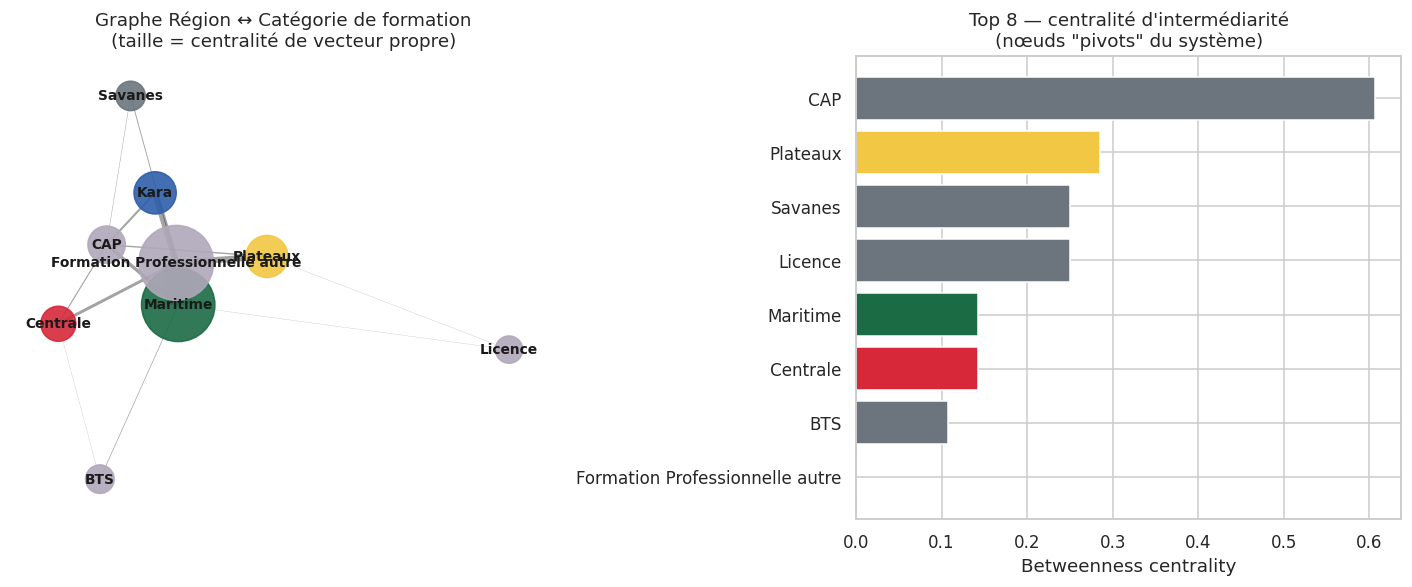

Régions pivots (forte intermédiarité) : ['Plateaux', 'Savanes']
Catégorie de formation dominante (degré/eigenvector max) : Formation Professionnelle autre
Nœud(s) le(s) plus périphérique(s) (degré minimal) : ['Savanes', 'Kara', 'Licence', 'BTS']


In [29]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

pos = nx.spring_layout(G1, seed=42, weight="weight", k=0.9)
node_colors = [REGION_COLORS.get(n, "#B0A8B9") for n in G1.nodes()]
node_sizes = [3000 * centralities.loc[n, "eigenvector"] + 300 for n in G1.nodes()]
edge_widths = [G1[u][v]["weight"] * 0.15 for u, v in G1.edges()]

nx.draw_networkx_nodes(G1, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=axes[0])
nx.draw_networkx_edges(G1, pos, width=edge_widths, alpha=0.4, ax=axes[0])
nx.draw_networkx_labels(G1, pos, font_size=9, font_weight="bold", ax=axes[0])
axes[0].set_title("Graphe Région ↔ Catégorie de formation\n(taille = centralité de vecteur propre)")
axes[0].axis("off")

top_between = centralities.sort_values("betweenness", ascending=False).head(8)
axes[1].barh(top_between.index, top_between["betweenness"],
             color=[REGION_COLORS.get(n, PALETTE[4]) for n in top_between.index])
axes[1].invert_yaxis()
axes[1].set_title("Top 8 — centralité d'intermédiarité\n(nœuds \"pivots\" du système)")
axes[1].set_xlabel("Betweenness centrality")

plt.tight_layout()
plt.show()

pivot_regions = [n for n in centralities.sort_values("betweenness", ascending=False).index if n in REGIONS][:2]
isolated = centralities[centralities["degree"] == centralities["degree"].min()]
print(f"Régions pivots (forte intermédiarité) : {pivot_regions}")
print(f"Catégorie de formation dominante (degré/eigenvector max) : {centralities[centralities['type']=='Catégorie']['eigenvector'].idxmax()}")
print(f"Nœud(s) le(s) plus périphérique(s) (degré minimal) : {list(isolated.index)}")


### 10.2 Graphe hiérarchique Région → Préfecture → Établissement (structure territoriale réelle)

In [30]:

G2 = nx.Graph()
G2.add_node("Togo", level=0)
for r in REGIONS:
    G2.add_node(r, level=1)
    G2.add_edge("Togo", r)

for _, row in df_etab.dropna(subset=["prefecture_nom_bdd"]).drop_duplicates(
        subset=["region_nom_bdd", "prefecture_nom_bdd"]).iterrows():
    G2.add_node(row["prefecture_nom_bdd"], level=2)
    G2.add_edge(row["region_nom_bdd"], row["prefecture_nom_bdd"])

prefecture_deg = df_etab.groupby("prefecture_nom_bdd").size()
for pref, n_etab in prefecture_deg.items():
    G2.nodes[pref]["nb_etablissements"] = int(n_etab)

print(f"Graphe territorial : {G2.number_of_nodes()} nœuds "
      f"(1 pays + {len(REGIONS)} régions + {df_etab['prefecture_nom_bdd'].nunique()} préfectures), "
      f"{G2.number_of_edges()} arêtes")

deg_cent2 = nx.degree_centrality(G2)
between_cent2 = nx.betweenness_centrality(G2)
top_prefectures = prefecture_deg.sort_values(ascending=False).head(10)
print("\nTop 10 préfectures les mieux dotées en établissements de formation technique :")
display(top_prefectures.rename("nb_etablissements"))


Graphe territorial : 38 nœuds (1 pays + 5 régions + 32 préfectures), 37 arêtes

Top 10 préfectures les mieux dotées en établissements de formation technique :


prefecture_nom_bdd
Golfe         97
Agoè-Nyivé    53
Kozah         23
Kloto         17
Tchaoudjo     13
Ogou           4
Haho           4
Anié           4
Oti            3
Doufelgou      3
Name: nb_etablissements, dtype: int64

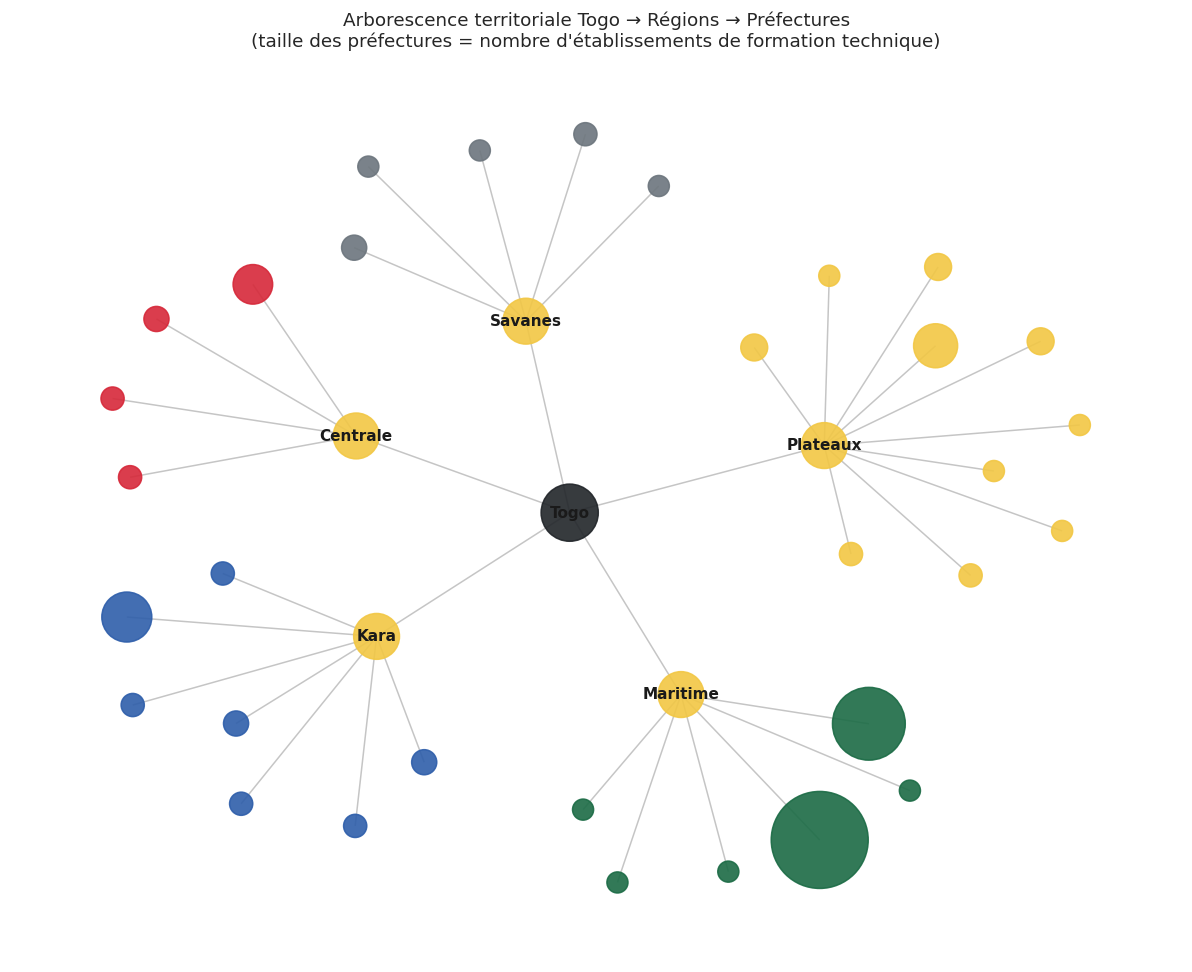

In [31]:

fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.kamada_kawai_layout(G2)

level_colors = {0: "#212529", 1: "#F2C744"}
colors = []
sizes = []
for n in G2.nodes():
    lvl = G2.nodes[n].get("level")
    if lvl in (0, 1):
        colors.append(level_colors[lvl])
        sizes.append(1400 if lvl == 0 else 900)
    else:
        parent_region = next((r for r in REGIONS if r in G2.neighbors(n)), None)
        colors.append(REGION_COLORS.get(parent_region, "#B0A8B9"))
        sizes.append(150 + G2.nodes[n].get("nb_etablissements", 0) * 40)

nx.draw_networkx_edges(G2, pos, alpha=0.25, ax=ax)
nx.draw_networkx_nodes(G2, pos, node_color=colors, node_size=sizes, alpha=0.9, ax=ax)
labels = {n: n for n in G2.nodes() if G2.nodes[n].get("level", 2) <= 1}
nx.draw_networkx_labels(G2, pos, labels=labels, font_size=10, font_weight="bold", ax=ax)
ax.set_title("Arborescence territoriale Togo → Régions → Préfectures\n(taille des préfectures = nombre d'établissements de formation technique)")
ax.axis("off")
plt.tight_layout()
plt.show()


### 10.3 Graphe Établissements ↔ Villes (2018) — PageRank et communautés de Louvain

Construit à partir de la donnée réelle de répartition des établissements d'enseignement supérieur. Chaque ville
est reliée à un nœud "type × statut" (ex. *Université Publique*) avec un poids = nombre d'établissements.


In [32]:
G3 = nx.Graph()
combo = df_repart.copy()
combo["type_statut"] = combo["type"] + " " + combo["statut"]

for v in combo["villes"].unique():
    G3.add_node(v, kind="ville")
for ts in combo["type_statut"].unique():
    G3.add_node(ts, kind="type_statut")

grouped = combo.groupby(["villes", "type_statut"])["Value"].sum()
for (v, ts), w in grouped.items():
    if w > 0:
        G3.add_edge(v, ts, weight=float(w))

# Retirer les villes totalement isolées (aucune structure recensée en 2018)
G3.remove_nodes_from(list(nx.isolates(G3)))

pagerank = nx.pagerank(G3, weight="weight")
partition = community_louvain.best_partition(G3, weight="weight", random_state=42)

# Correction: Construire le DataFrame de manière à garantir l'alignement des données
result3 = pd.DataFrame({
    "pagerank": pd.Series(pagerank),
    "communaute_louvain": pd.Series(partition),
    "type": ["Ville" if G3.nodes[n]["kind"] == "ville" else "Type×Statut" for n in G3.nodes()]
}).sort_values("pagerank", ascending=False)

display(result3.round(4))

print(f"Nombre de communautés détectées (Louvain) : {result3['communaute_louvain'].nunique()}")
print(f"Nœud au PageRank le plus élevé : {result3.index[0]} (secteur/ville le plus 'central' du réseau)")

,pagerank,communaute_louvain,type
Etablissement Prive,0.4037,0,Type×Statut
LOMÉ,0.3368,0,Ville
KARA,0.0586,1,Ville
Etablissement Public,0.0358,1,Type×Statut
SOKODÉ,0.0295,0,Ville
Université Public,0.0258,1,Type×Statut
DAPAONG,0.0242,0,Ville
ATAKPAMÉ,0.0242,0,Ville
Université Prive,0.0237,0,Type×Statut
AFANGNAN,0.0189,0,Ville


Nombre de communautés détectées (Louvain) : 2
Nœud au PageRank le plus élevé : Etablissement Prive (secteur/ville le plus 'central' du réseau)


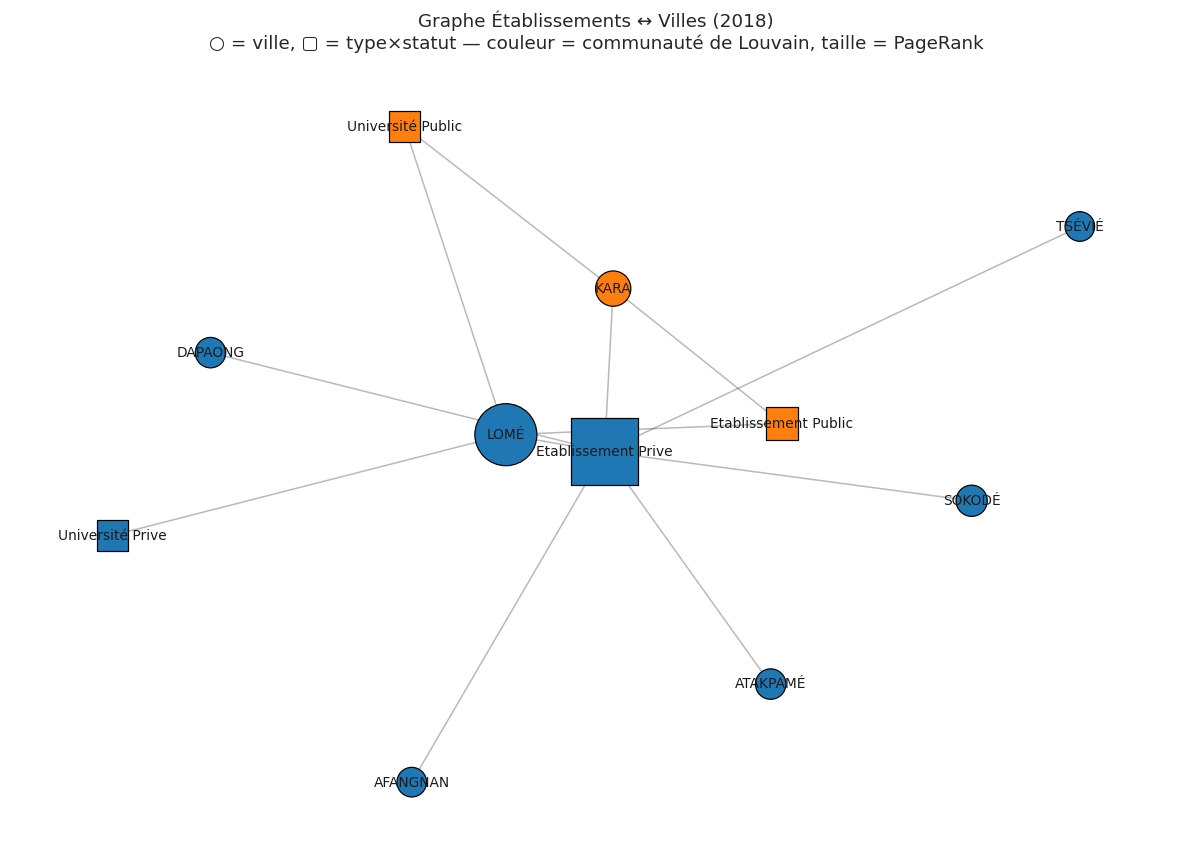

In [33]:

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G3, seed=7, weight="weight", k=1.1)

cmap = plt.cm.tab10
node_colors = [cmap(partition[n] % 10) for n in G3.nodes()]
node_sizes = [4000 * pagerank[n] + 200 for n in G3.nodes()]
shapes_villes = [n for n in G3.nodes() if G3.nodes[n]["kind"] == "ville"]
shapes_types = [n for n in G3.nodes() if G3.nodes[n]["kind"] == "type_statut"]

nx.draw_networkx_edges(G3, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G3, pos, nodelist=shapes_villes,
                        node_color=[cmap(partition[n] % 10) for n in shapes_villes],
                        node_size=[4000 * pagerank[n] + 300 for n in shapes_villes],
                        node_shape="o", edgecolors="black", linewidths=0.8, ax=ax)
nx.draw_networkx_nodes(G3, pos, nodelist=shapes_types,
                        node_color=[cmap(partition[n] % 10) for n in shapes_types],
                        node_size=[4000 * pagerank[n] + 300 for n in shapes_types],
                        node_shape="s", edgecolors="black", linewidths=0.8, ax=ax)
nx.draw_networkx_labels(G3, pos, font_size=9, ax=ax)
ax.set_title("Graphe Établissements ↔ Villes (2018)\n○ = ville, ▢ = type×statut — couleur = communauté de Louvain, taille = PageRank")
ax.axis("off")
plt.tight_layout()
plt.show()


### 10.4 Graphe global multi-niveaux (interactif)

Grand graphe reliant **Région → Préfecture → Établissement de formation technique → Catégorie → Secteur estimé**,
conformément à la structure demandée, dans la limite des données disponibles (les niveaux *Diplôme → Secteur
d'emploi → Chômage* ne peuvent être rattachés individuellement à chaque établissement, cf. §2 ; ils sont
représentés au niveau agrégé national dans le tableau de bord, section 15).


In [34]:

net = Network(height="720px", width="100%", bgcolor="#ffffff", font_color="#212121", notebook=True, cdn_resources="in_line")
net.barnes_hut(gravity=-4000, central_gravity=0.3, spring_length=110, spring_strength=0.02, damping=0.9)

net.add_node("TOGO", label="TOGO", color="#212529", size=40, shape="star", level=0)
for r in REGIONS:
    net.add_node(r, label=r, color=REGION_COLORS[r], size=32, level=1, title=f"Région : {r}")
    net.add_edge("TOGO", r)

# Préfectures
prefectures_df = df_etab.dropna(subset=["prefecture_nom_bdd"]).drop_duplicates(subset=["prefecture_nom_bdd"])
for _, row in prefectures_df.iterrows():
    pid = f"PREF::{row['prefecture_nom_bdd']}"
    net.add_node(pid, label=row["prefecture_nom_bdd"], color=REGION_COLORS[row["region_nom_bdd"]],
                 size=16, level=2, title=f"Préfecture : {row['prefecture_nom_bdd']}")
    net.add_edge(row["region_nom_bdd"], pid)

# Catégories (niveau intermédiaire, connectées aux préfectures via les établissements qu'elles regroupent)
cat_colors = dict(zip(categories, px.colors.qualitative.Set2))
for c in categories:
    net.add_node(f"CAT::{c}", label=c, color="#495057", size=22, shape="diamond", level=4,
                 title=f"Catégorie de formation : {c}")

# Secteurs estimés (niveau terminal)
sectors = df_etab["secteur_estime"].unique()
for s in sectors:
    net.add_node(f"SECT::{s}", label=s, color="#adb5bd", size=18, shape="triangle", level=5,
                 title=f"⚠️ Secteur estimé : {s}")

# Etablissements (échantillonnés si trop nombreux pour rester lisible -> on garde tout, le graphe reste gérable à 256 noeuds)
for _, row in df_etab.iterrows():
    eid = f"ETAB::{row.name}"
    pid = f"PREF::{row['prefecture_nom_bdd']}" if pd.notna(row["prefecture_nom_bdd"]) else None
    net.add_node(eid, label="", color="#F2C744", size=6, level=3,
                 title=f"{row['etab_nom']} ({row['region_nom_bdd']}, {row['prefecture_nom_bdd']})")
    if pid:
        net.add_edge(pid, eid)
    if pd.notna(row["etablissement_categorie"]):
        net.add_edge(eid, f"CAT::{row['etablissement_categorie']}")
    net.add_edge(eid, f"SECT::{row['secteur_estime']}")

net.set_options('''
{
  "layout": {"hierarchical": {"enabled": false}},
  "physics": {"stabilization": {"iterations": 150}},
  "interaction": {"hover": true, "tooltipDelay": 100}
}
''')

net.save_graph("graphe_global_togo.html")
print("Graphe global sauvegardé -> graphe_global_togo.html")
print(f"{net.num_nodes()} nœuds, {net.num_edges()} arêtes.")
IFrame("graphe_global_togo.html", width="100%", height=740)


Graphe global sauvegardé -> graphe_global_togo.html
307 nœuds, 783 arêtes.


> 💡 *Astuce d'usage* : le graphe ci-dessus est **interactif** — zoomez, faites glisser les nœuds, survolez un
> point jaune pour voir le nom de l'établissement concerné. TOGO ⟶ Région ⟶ Préfecture ⟶ Établissement ⟶
> Catégorie / Secteur estimé.


<a id="11"></a>
## 11. Machine Learning — modélisation exploratoire du chômage des diplômés

> ⚠️ **Avertissement à lire avant cette section.** Le chômage des diplômés du supérieur n'est connu, dans les
> données fournies, qu'à l'échelle **nationale** et sur **6 années seulement** (2006, 2011, 2015, 2017, 2019,
> 2022). Il n'existe **aucune donnée réelle de chômage par filière, diplôme ou région**. Le cahier des charges
> demande un modèle « estimant le niveau de chômage d'une filière » : cela **n'est pas réalisable
> honnêtement** avec les données transmises. Ce qui suit est donc un **exercice pédagogique de bout en bout**
> (préparation, entraînement, validation croisée, comparaison de modèles, importance des variables) appliqué à
> la seule cible disponible — le chômage **national** — avec un échantillon de **6 observations**. Les
> performances obtenues n'ont **aucune valeur prédictive opérationnelle** : l'objectif est de démontrer la
> méthode, pas de livrer un outil de prévision fiable.

### 11.1 Constitution du jeu de données (interpolation transparente)


In [35]:

years_range = range(1995, 2024)
ml_base = pd.DataFrame(index=years_range)
ml_base = ml_base.join(wb_inscription).join(wb_depense)
ml_base.index.name = "annee"

# On mémorise quelles valeurs sont réellement observées avant interpolation (transparence totale)
observed_mask = ml_base.notna()

ml_interp = ml_base.interpolate(method="linear", limit_direction="both")
ml_interp["annee"] = ml_interp.index

target_years = wb_chomage.index.tolist()
dataset = ml_interp.loc[target_years].copy()
dataset["chomage_diplomes_pct"] = wb_chomage.loc[target_years, "chomage_diplomes_pct"]

# Annotation transparence : la valeur était-elle réellement observée cette année-là ?
for col in ["taux_brut_inscription_tertiaire", "depense_etud_pct_pib_hab"]:
    dataset[f"{col}__observe"] = observed_mask.reindex(target_years)[col].values

display(dataset)
print(f"\nJeu de données final pour le ML : {dataset.shape[0]} observations, cible = chomage_diplomes_pct")
print("Les colonnes '__observe' indiquent si la valeur était mesurée cette année précise (True) ",
      "ou interpolée/extrapolée depuis les années voisines (False) — cf. avertissement ci-dessus.")


,taux_brut_inscription_tertiaire,depense_etud_pct_pib_hab,annee,chomage_diplomes_pct,taux_brut_inscription_tertiaire__observe,depense_etud_pct_pib_hab__observe
annee,,,,,,
2022,15.06594,77.171350,2022,7.068,False,False
2019,13.32342,77.171350,2019,12.622,True,False
2017,12.52330,77.171350,2017,13.489,True,True
2015,11.03913,91.098070,2015,8.227,True,True
2011,9.90193,71.723940,2011,6.952,True,True
2006,5.08457,153.033117,2006,11.678,True,False



Jeu de données final pour le ML : 6 observations, cible = chomage_diplomes_pct
Les colonnes '__observe' indiquent si la valeur était mesurée cette année précise (True)  ou interpolée/extrapolée depuis les années voisines (False) — cf. avertissement ci-dessus.


### 11.2 Comparaison de modèles (validation croisée Leave-One-Out, adaptée aux très petits échantillons)

In [36]:

feature_cols = ["annee", "taux_brut_inscription_tertiaire", "depense_etud_pct_pib_hab"]
X = dataset[feature_cols].values
y = dataset["chomage_diplomes_pct"].values

loo = LeaveOneOut()
models = {
    "Régression linéaire": LinearRegression(),
    "Arbre de décision": DecisionTreeRegressor(max_depth=2, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42, verbosity=0),
}

results = []
for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=loo)
    mae = mean_absolute_error(y, preds)
    rmse = mean_squared_error(y, preds) ** 0.5
    r2 = r2_score(y, preds)
    results.append({"Modèle": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R²": round(r2, 2)})

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

print("⚠️ Avec n=6, le R² peut être négatif ou instable : ce n'est PAS un signe d'échec du code, mais la",
      "conséquence arithmétique attendue d'un échantillon aussi réduit. À interpréter uniquement de façon relative",
      "(quel modèle se trompe le moins sur ce petit échantillon), jamais en valeur absolue.")


,Modèle,MAE,RMSE,R²
3,Gradient Boosting,3.44,3.73,-0.95
2,Random Forest,3.46,3.69,-0.90
4,XGBoost,3.88,4.23,-1.51
1,Arbre de décision,4.10,4.37,-1.67
0,Régression linéaire,10.97,13.64,-25.02


⚠️ Avec n=6, le R² peut être négatif ou instable : ce n'est PAS un signe d'échec du code, mais la conséquence arithmétique attendue d'un échantillon aussi réduit. À interpréter uniquement de façon relative (quel modèle se trompe le moins sur ce petit échantillon), jamais en valeur absolue.


### 11.3 Importance des variables (modèle Random Forest, entraîné sur l'ensemble des données disponibles)

In [37]:

rf_final = RandomForestRegressor(n_estimators=300, max_depth=3, random_state=42).fit(X, y)
importance = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig = px.bar(importance.reset_index(), x="index", y=0, color=0, color_continuous_scale="Teal",
             labels={"index": "Variable", "0": "Importance (Random Forest)"},
             title="Importance des variables — modèle Random Forest (échantillon n=6, résultat indicatif ⚠️)")
fig.update_layout(height=400, margin=dict(t=60, b=10), showlegend=False, coloraxis_showscale=False)
fig.show()

display(importance.rename("importance"))


annee                              0.362664
taux_brut_inscription_tertiaire    0.327056
depense_etud_pct_pib_hab           0.310281
Name: importance, dtype: float64

> **Conclusion de la section ML** : la démarche complète (préparation → modélisation → validation croisée →
> importance des variables) est fonctionnelle et reproductible, mais **la donnée manquante est le facteur
> limitant**, pas la méthode. Une vraie estimation du chômage par filière nécessiterait une **enquête de
> traçabilité des diplômés (tracer study)** ventilée par filière, diplôme et région — donnée à collecter en
> priorité par le Ministère (cf. recommandations, section 14).


<a id="12"></a>
## 12. Segmentation des régions (clustering)

> ⚠️ Le Togo compte **5 régions** : il ne s'agit pas d'un échantillon statistique mais de la **population
> complète**. Le clustering ci-dessous doit donc être lu comme un **outil de regroupement visuel** des profils
> régionaux, pas comme une découverte de patterns généralisables à plus grande échelle.

### 12.1 Construction des variables régionales (toutes réelles ou directement agrégées)


In [38]:

region_features = cover_df.set_index("region")[["nb_etablissements", "population_2022", "etab_pour_100k_hab"]].copy()

diversite_categorie = df_etab.groupby("region_nom_bdd")["etablissement_categorie"].nunique()
diversite_secteur = df_etab.groupby("region_nom_bdd")["secteur_estime"].nunique()
part_recentes = df_etab.dropna(subset=["annee_creation"]).assign(
    recent=lambda d: d["annee_creation"] >= 2010).groupby("region_nom_bdd")["recent"].mean() * 100

sup_2018_region = df_repart.groupby("region")["Value"].sum()

region_features["diversite_categories"] = diversite_categorie
region_features["diversite_secteurs_estimes"] = diversite_secteur
region_features["part_creations_recentes_pct"] = part_recentes
region_features["nb_etab_sup_2018"] = sup_2018_region.reindex(region_features.index).fillna(0)
region_features = region_features.reindex(REGIONS)

display(region_features.round(2))


,nb_etablissements,population_2022,etab_pour_100k_hab,diversite_categories,diversite_secteurs_estimes,part_creations_recentes_pct,nb_etab_sup_2018
region,,,,,,,
Maritime,154,3534991,4.36,4,7,50.00,58
Plateaux,37,1635946,2.26,3,3,46.88,2
Centrale,20,795529,2.51,3,5,36.84,3
Kara,37,985512,3.75,2,7,57.14,7
Savanes,8,1143520,0.70,2,2,71.43,3


### 12.2 KMeans, DBSCAN, Classification Ascendante Hiérarchique

In [39]:

feat_cols = ["nb_etablissements", "etab_pour_100k_hab", "diversite_categories",
             "diversite_secteurs_estimes", "part_creations_recentes_pct", "nb_etab_sup_2018"]

Xr = StandardScaler().fit_transform(region_features[feat_cols].fillna(0))

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xr)
dbscan = DBSCAN(eps=1.6, min_samples=2).fit(Xr)
agglo = AgglomerativeClustering(n_clusters=3).fit(Xr)

clusters = region_features.copy()
clusters["KMeans"] = kmeans.labels_
clusters["DBSCAN"] = dbscan.labels_
clusters["Agglomerative"] = agglo.labels_
display(clusters[["KMeans", "DBSCAN", "Agglomerative"]])


,KMeans,DBSCAN,Agglomerative
region,,,
Maritime,2,-1,1
Plateaux,1,0,0
Centrale,1,0,0
Kara,1,-1,0
Savanes,0,-1,2


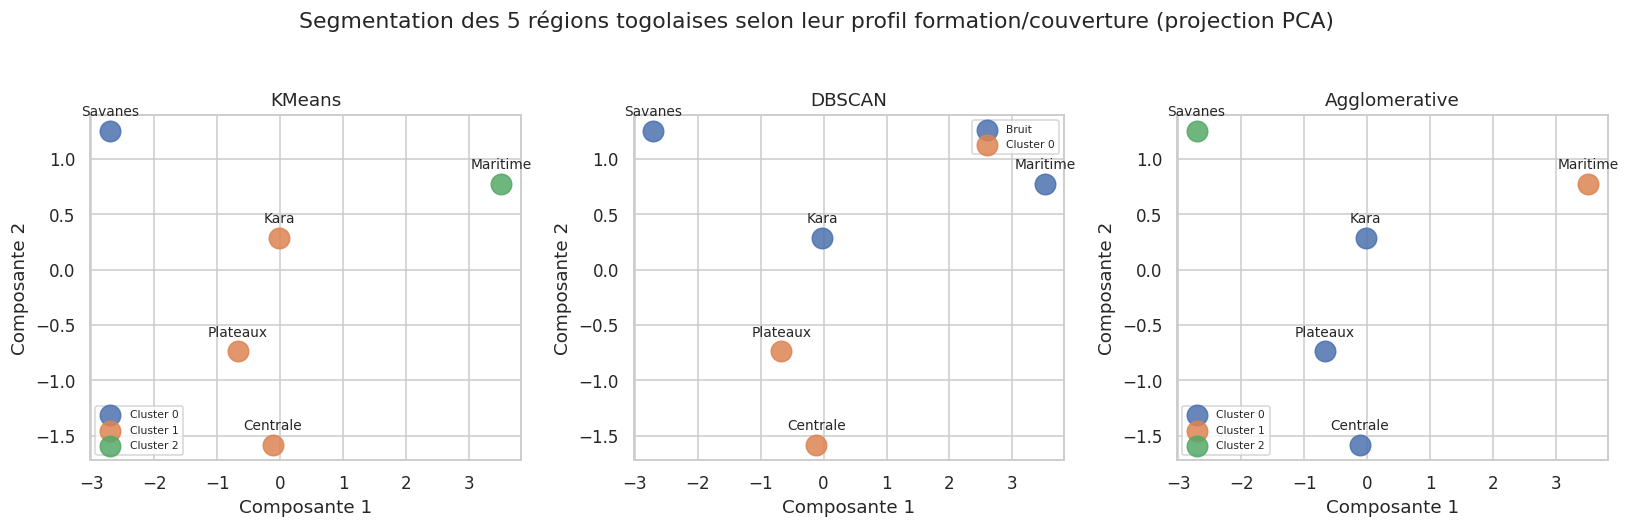

In [40]:

from sklearn.decomposition import PCA
coords_pca = PCA(n_components=2, random_state=42).fit_transform(Xr)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, method in zip(axes, ["KMeans", "DBSCAN", "Agglomerative"]):
    labels = clusters[method].values
    for lbl in sorted(set(labels)):
        mask = labels == lbl
        ax.scatter(coords_pca[mask, 0], coords_pca[mask, 1], s=180,
                   label=f"Cluster {lbl}" if lbl != -1 else "Bruit", alpha=0.85)
    for i, r in enumerate(region_features.index):
        ax.annotate(r, (coords_pca[i, 0], coords_pca[i, 1]), fontsize=9, ha="center", va="bottom",
                    xytext=(0, 8), textcoords="offset points")
    ax.set_title(method)
    ax.legend(fontsize=7)
    ax.set_xlabel("Composante 1"); ax.set_ylabel("Composante 2")

plt.suptitle("Segmentation des 5 régions togolaises selon leur profil formation/couverture (projection PCA)", y=1.04)
plt.tight_layout()
plt.show()


**Lecture qualitative** — la Maritime se distingue nettement (volume et diversité les plus élevés, portés par
Lomé), tandis que les autres régions se regroupent selon leur niveau de couverture relative et la fraîcheur de
leur offre (part des établissements créés depuis 2010).


<a id="13"></a>
## 13. Indicateurs composites inédits

Quatre scores originaux, construits pour ce concours, combinant les variables **régionales réelles**
disponibles avec les **indicateurs nationaux** (appliqués uniformément aux régions et signalés ⚠️ lorsque c'est
le cas, faute de régionalisation dans les données fournies).

### 13.1 Formation-Employment Alignment Score (FEAS) — 0 à 100


In [41]:

def minmax_100(s):
    if s.max() == s.min():
        return pd.Series(50.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

rf = region_features.copy()

# --- Composantes régionales réelles ---
c_couverture = minmax_100(rf["etab_pour_100k_hab"])
c_diversite = minmax_100(rf["diversite_categories"] + rf["diversite_secteurs_estimes"])
c_dynamisme = minmax_100(rf["part_creations_recentes_pct"])
c_volume_sup = minmax_100(rf["nb_etab_sup_2018"])

# --- Composantes nationales, appliquées uniformément (⚠️) ---
ratio_national = ind_wide["ratio_etud_enseignant"].dropna().iloc[-1]
c_encadrement_national = max(0, 100 - (ratio_national / 2))          # ratio plus faible = meilleur encadrement
part_sci_national = ind_wide["pct_filieres_scientifiques"].dropna().iloc[-1]
c_orientation_sci_national = min(100, part_sci_national / 40 * 100)   # 40% = cible de référence retenue
exec_budget_national = budget_wide["taux_execution_sup"].mean()
c_execution_budget_national = min(100, exec_budget_national)

WEIGHTS = {
    "couverture_territoriale": 0.25,
    "diversite_offre": 0.20,
    "dynamisme_creations": 0.15,
    "volume_enseignement_sup": 0.15,
    "encadrement_national": 0.10,
    "orientation_scientifique_national": 0.10,
    "execution_budgetaire_national": 0.05,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

feas = pd.DataFrame({
    "couverture_territoriale": c_couverture,
    "diversite_offre": c_diversite,
    "dynamisme_creations": c_dynamisme,
    "volume_enseignement_sup": c_volume_sup,
    "encadrement_national": c_encadrement_national,
    "orientation_scientifique_national": c_orientation_sci_national,
    "execution_budgetaire_national": c_execution_budget_national,
}, index=rf.index)

feas["FEAS"] = sum(feas[c] * w for c, w in WEIGHTS.items()).round(1)
feas_sorted = feas.sort_values("FEAS", ascending=False)
display(feas_sorted.round(1))

print("Formule : FEAS = " + " + ".join(f"{w:.0%}×{c}" for c, w in WEIGHTS.items()))
print("\nClassement FEAS :", list(feas_sorted.index))


,couverture_territoriale,diversite_offre,dynamisme_creations,volume_enseignement_sup,encadrement_national,orientation_scientifique_national,execution_budgetaire_national,FEAS
region,,,,,,,,
Maritime,100.0,100.0,38.0,100.0,54.5,59.0,92.9,81.7
Kara,83.3,71.4,58.7,8.9,54.5,59.0,92.9,61.3
Centrale,49.5,57.1,0.0,1.8,54.5,59.0,92.9,40.1
Plateaux,42.6,28.6,29.0,0.0,54.5,59.0,92.9,36.7
Savanes,0.0,0.0,100.0,1.8,54.5,59.0,92.9,31.3


Formule : FEAS = 25%×couverture_territoriale + 20%×diversite_offre + 15%×dynamisme_creations + 15%×volume_enseignement_sup + 10%×encadrement_national + 10%×orientation_scientifique_national + 5%×execution_budgetaire_national

Classement FEAS : ['Maritime', 'Kara', 'Centrale', 'Plateaux', 'Savanes']


In [42]:

fig = px.bar(feas_sorted.reset_index(), x="region", y="FEAS", color="FEAS",
             color_continuous_scale="RdYlGn", range_color=[0, 100],
             text=feas_sorted["FEAS"].round(1),
             title="Formation-Employment Alignment Score (FEAS) par région — 0 à 100",
             labels={"region": "Région", "FEAS": "Score FEAS"})
fig.update_traces(textposition="outside")
fig.update_layout(height=430, margin=dict(t=60, b=10), coloraxis_showscale=False)
fig.show()


### 13.2 Trois scores complémentaires

- **Opportunity Index** : régions à forte population mais faible couverture actuelle → potentiel d'investissement prioritaire (100% régional, réel).
- **Territorial Equity Score** : équité de répartition de l'offre rapportée à la population, mesurée par un indice de dispersion inspiré du Gini (100% régional, réel).
- **Employment Potential Score ⚠️** : potentiel théorique d'absorption en emploi, combinant diversité sectorielle réelle/estimée et dynamisme réel — proxy, faute de données d'insertion professionnelle réelles.


In [43]:

# --- Opportunity Index (réel, régional) : forte population x faible couverture relative ---
pop_share = rf["population_2022"] / rf["population_2022"].sum() * 100
coverage_share = minmax_100(rf["etab_pour_100k_hab"])
opportunity_index = minmax_100(pop_share * (100 - coverage_share)).round(1)

# --- Territorial Equity Score (réel, régional) : 100 - dispersion relative (type Gini simplifié) ---
values = rf["etab_pour_100k_hab"].values
mad = np.mean([abs(vi - vj) for vi in values for vj in values]) / 2
gini_like = mad / np.mean(values)
# Score d'équité identique pour toutes les régions (c'est une propriété du système, pas d'une région isolée)
equity_score_system = round(max(0, 100 - gini_like * 100), 1)

# --- Employment Potential Score (proxy ⚠️, régional) ---
employment_potential = minmax_100(0.6 * (rf["diversite_categories"] + rf["diversite_secteurs_estimes"]) +
                                    0.4 * rf["part_creations_recentes_pct"]).round(1)

scores_df = pd.DataFrame({
    "FEAS": feas["FEAS"],
    "Opportunity Index": opportunity_index,
    "Employment Potential Score ⚠️": employment_potential,
})
scores_df["Territorial Equity Score (système, ⚠️ valeur unique)"] = equity_score_system
display(scores_df.round(1))

print(f"\nScore d'équité territoriale du système (0=très inégalitaire, 100=parfaitement équitable) : {equity_score_system}/100")
print("Région avec le plus fort potentiel d'opportunité (population importante, couverture relative faible) :",
      opportunity_index.idxmax())


,FEAS,Opportunity Index,Employment Potential Score ⚠️,"Territorial Equity Score (système, ⚠️ valeur unique)"
region,,,,
Maritime,81.7,0.0,61.8,74.1
Plateaux,36.7,82.1,24.6,74.1
Centrale,40.1,35.2,0.0,74.1
Kara,61.3,14.4,76.3,74.1
Savanes,31.3,100.0,100.0,74.1



Score d'équité territoriale du système (0=très inégalitaire, 100=parfaitement équitable) : 74.1/100
Région avec le plus fort potentiel d'opportunité (population importante, couverture relative faible) : Savanes


In [44]:

categories_radar = ["FEAS", "Opportunity Index", "Employment Potential Score ⚠️"]
fig = go.Figure()
for r in REGIONS:
    vals = scores_df.loc[r, categories_radar].tolist()
    fig.add_trace(go.Scatterpolar(r=vals + [vals[0]], theta=categories_radar + [categories_radar[0]],
                                   fill="toself", name=r, line=dict(color=REGION_COLORS[r])))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
                   title="Comparatif régional — scores composites (radar)", height=520, margin=dict(t=60, b=10))
fig.show()


<a id="14"></a>
## 14. Recommandations stratégiques générées automatiquement

Les recommandations ci-dessous sont **produites par une fonction de règles** appliquée aux résultats calculés
plus haut dans le notebook (pas rédigées a priori) : si les données changent, les recommandations changent
avec elles.


In [45]:

recommendations = []

# 1. Couverture territoriale
region_faible = cover_df.sort_values("etab_pour_100k_hab").iloc[0]
region_forte = cover_df.sort_values("etab_pour_100k_hab", ascending=False).iloc[0]
recommendations.append(
    f"🗺️ **Rééquilibrer l'offre territoriale** : la région **{region_faible['region']}** affiche la couverture "
    f"la plus faible ({region_faible['etab_pour_100k_hab']:.1f} établissements/100k hab. contre "
    f"{region_forte['etab_pour_100k_hab']:.1f} pour {region_forte['region']}). Prioriser l'ouverture de "
    f"nouveaux centres de formation technique dans cette région, en cohérence avec son Opportunity Index "
    f"({opportunity_index[region_faible['region']]:.0f}/100)."
)

# 2. Formations saturées / porteuses (proxy)
recommendations.append(
    f"⚠️ **Vérifier le risque de saturation** de la catégorie **{risk.index[0]}** (indice proxy le plus élevé, "
    f"{risk.iloc[0]['indice_saturation_proxy']:.0f}/100) par une véritable enquête d'insertion professionnelle, "
    f"avant d'autoriser de nouvelles ouvertures dans cette catégorie. À l'inverse, la catégorie "
    f"**{risk.index[-1]}** apparaît sous-représentée et pourrait justifier un soutien ciblé."
)

# 3. Filières scientifiques et féminisation
recommendations.append(
    f"🔬 **Renforcer les filières scientifiques et technologiques**, qui ne représentent que "
    f"{ind_wide['pct_filieres_scientifiques'].dropna().iloc[-1]:.1f}% des effectifs du supérieur, avec un "
    f"accent particulier sur la féminisation de ces filières, où les filles ne représentent que "
    f"{ind_wide['pct_filles_filieres_sci'].dropna().iloc[-1]:.1f}% des inscrits (contre "
    f"{ind_wide['taux_feminisation'].dropna().iloc[-1]:.1f}% de féminisation globale)."
)

# 4. Encadrement
recommendations.append(
    f"👩‍🏫 **Poursuivre l'effort d'encadrement** : le ratio étudiants/enseignant s'est amélioré (128 → "
    f"{ind_wide['ratio_etud_enseignant'].dropna().iloc[-1]:.0f} entre 2016 et sa dernière valeur connue), un "
    f"effort à maintenir face à la croissance continue des effectifs "
    f"({int(ind_wide['effectifs_etudiants'].dropna().iloc[-1]):,} étudiants inscrits en dernière année connue)."
    .replace(",", " ")
)

# 5. Investissement (FEAS le plus faible)
region_feas_faible = feas_sorted.index[-1]
recommendations.append(
    f"💰 **Cibler l'investissement** sur la région **{region_feas_faible}**, qui affiche le FEAS le plus bas "
    f"({feas_sorted.loc[region_feas_faible, 'FEAS']:.0f}/100) — combinaison de couverture, diversité et "
    f"dynamisme de l'offre les plus faibles du pays."
)

# 6. Données manquantes à collecter en priorité
recommendations.append(
    "📋 **Combler le déficit de données** identifié en section 2 : sans (i) une nomenclature de filières/"
    "spécialités renseignée systématiquement, (ii) une exécution budgétaire régionalisée, et (iii) une enquête "
    "de traçabilité des diplômés par filière, aucune analyse d'adéquation Formation-Emploi ne pourra dépasser le "
    "stade de l'estimation indicative présentée ici."
)

for i, r in enumerate(recommendations, 1):
    display(HTML(f"<div style='padding:10px 14px;margin:6px 0;border-left:4px solid {PALETTE[i % len(PALETTE)]};"
                  f"background:#f8f9fa;border-radius:4px'>{i}. {r}</div>"))


<a id="15"></a>
## 15. Tableau de bord de synthèse

Une dernière série de visualisations Plotly rassemble les familles de graphes demandées qui n'ont pas encore
été mobilisées (treemap, sankey, bulles, coordonnées parallèles, histogramme), pour une lecture d'ensemble.

### 15.1 Treemap — répartition Région → Préfecture → Catégorie


In [46]:

tm = df_etab.dropna(subset=["etablissement_categorie"]).copy()
fig = px.treemap(
    tm, path=[px.Constant("Togo"), "region_nom_bdd", "prefecture_nom_bdd", "etablissement_categorie"],
    color="region_nom_bdd", color_discrete_map={**REGION_COLORS, "(?)": "#ccc"},
    title="Treemap — Togo → Région → Préfecture → Catégorie de formation",
)
fig.update_layout(height=560, margin=dict(t=60, b=10))
fig.show()


### 15.2 Sankey — flux Région → Catégorie → Secteur estimé ⚠️

In [47]:

sk = df_etab.dropna(subset=["etablissement_categorie"]).copy()
regions_u = sorted(sk["region_nom_bdd"].unique())
cats_u = sorted(sk["etablissement_categorie"].unique())
sects_u = sorted(sk["secteur_estime"].unique())

labels = regions_u + cats_u + sects_u
idx = {lab: i for i, lab in enumerate(labels)}
node_colors = ([REGION_COLORS[r] for r in regions_u] + ["#495057"] * len(cats_u) + ["#adb5bd"] * len(sects_u))

link_src, link_tgt, link_val = [], [], []
flow1 = sk.groupby(["region_nom_bdd", "etablissement_categorie"]).size()
for (r, c), v in flow1.items():
    link_src.append(idx[r]); link_tgt.append(idx[c]); link_val.append(int(v))

flow2 = sk.groupby(["etablissement_categorie", "secteur_estime"]).size()
for (c, s), v in flow2.items():
    link_src.append(idx[c]); link_tgt.append(idx[s]); link_val.append(int(v))

fig = go.Figure(go.Sankey(
    node=dict(label=labels, color=node_colors, pad=14, thickness=16),
    link=dict(source=link_src, target=link_tgt, value=link_val, color="rgba(150,150,150,0.35)"),
))
fig.update_layout(title="⚠️ Flux Région → Catégorie de formation → Secteur estimé (heuristique pour le dernier niveau)",
                   height=560, margin=dict(t=60, b=10), font_size=11)
fig.show()


### 15.3 Bulles — population régionale, offre de formation et score FEAS

In [48]:

bubble = region_features.copy()
bubble["FEAS"] = feas["FEAS"]

fig = px.scatter(
    bubble.reset_index(), x="population_2022", y="nb_etablissements", size="FEAS", color="region",
    color_discrete_map=REGION_COLORS, size_max=55, text=bubble.index,
    title="Population régionale vs offre de formation technique (taille = score FEAS)",
    labels={"population_2022": "Population (RGPH-5, 2022)", "nb_etablissements": "Nb établissements de formation technique"},
)
fig.update_traces(textposition="top center")
fig.update_layout(height=480, margin=dict(t=60, b=10))
fig.show()


### 15.4 Coordonnées parallèles — profils régionaux multidimensionnels

In [49]:

pc = region_features.copy()
pc["FEAS"] = feas["FEAS"]
pc["region_code"] = range(len(pc))

fig = px.parallel_coordinates(
    pc.reset_index(), color="FEAS", color_continuous_scale="RdYlGn",
    dimensions=["nb_etablissements", "etab_pour_100k_hab", "diversite_categories",
                "part_creations_recentes_pct", "nb_etab_sup_2018", "FEAS"],
    labels={"nb_etablissements": "Nb établissements", "etab_pour_100k_hab": "Étab./100k hab.",
            "diversite_categories": "Diversité catégories", "part_creations_recentes_pct": "% créations récentes",
            "nb_etab_sup_2018": "Nb étab. sup. 2018", "FEAS": "FEAS"},
    title="Profils régionaux multidimensionnels (coordonnées parallèles)",
)
fig.update_layout(height=480, margin=dict(t=60, b=10))
fig.show()
print("Ordre des régions (mêmes couleurs que les graphes précédents non garanti ici, cf. axe couleur = FEAS) :", list(pc.index))


Ordre des régions (mêmes couleurs que les graphes précédents non garanti ici, cf. axe couleur = FEAS) : ['Maritime', 'Plateaux', 'Centrale', 'Kara', 'Savanes']


### 15.5 Histogramme — ancienneté du parc d'établissements

In [50]:

fig = px.histogram(
    df_etab.dropna(subset=["annee_creation"]), x="annee_creation", color="region_nom_bdd", nbins=30,
    color_discrete_map=REGION_COLORS,
    title="Distribution des années de création des établissements de formation technique",
    labels={"annee_creation": "Année de création", "count": "Nombre d'établissements"},
)
fig.update_layout(height=440, margin=dict(t=60, b=10), bargap=0.05)
fig.show()


---
## Partie III — Synthèse décisionnelle et priorisation stratégique

Les sections 3 à 15 ont établi un **diagnostic complet**, fondé sur les données disponibles, de l'offre
de formation, des effectifs, des budgets et du chômage des diplômés. Les sections **16 à 23** qui
suivent franchissent une étape supplémentaire demandée par le cahier des charges du Défi 2 : elles
**synthétisent ce diagnostic en un indice unique (IAFE), le traduisent en priorités d'investissement
chiffrées, et les mettent en forme pour la décision publique** (classements, carte des priorités,
scénarios, Policy Dashboard).

### Boîte à outils — fonctions réutilisées dans les sections 16 à 23

Pour éviter toute répétition de code, trois fonctions génériques sont définies une seule fois
ci-dessous et réutilisées dans toute la suite du notebook (en complément de `minmax_100`, déjà définie
en §13.1). Les fonctions plus spécifiques à une seule section (ex. `diagnostic_offre_demande`,
`priority_bucket`) sont, elles, définies au plus près de leur premier usage, dans la section
correspondante.

In [51]:
# ==========================================================================
# BOITE A OUTILS — sections 16 à 23
# ==========================================================================
def fmt_fr(x, decimals=0):
    """Formate un nombre avec des espaces comme séparateurs de milliers (convention française)."""
    if pd.isna(x):
        return "n/d"
    return f"{x:,.{decimals}f}".replace(",", " ")


def score_national_in_history(series, invert=False, override_last=None):
    """Positionne une valeur annuelle nationale dans la plage historique OBSERVEE de sa
    propre série (0 = minimum historique, 100 = maximum historique, clippé si hors plage).
    Par défaut, positionne la dernière valeur réellement observée ; `override_last` permet
    de tester une valeur hypothétique (utilisé pour les scénarios prospectifs, §22).
    invert=True pour les indicateurs où une valeur plus faible est préférable (ex : chômage).
    Retourne (score_0_100, valeur_utilisee, annee_de_reference)."""
    s = series.dropna().sort_index()
    lo, hi = s.min(), s.max()
    val = override_last if override_last is not None else s.iloc[-1]
    pos = 50.0 if hi == lo else (val - lo) / (hi - lo) * 100
    pos = max(0.0, min(100.0, pos))
    score = (100 - pos) if invert else pos
    return round(score, 1), val, s.index[-1]


def styled_ranking(df, score_col, ascending=False, n=None, cmap="RdYlGn"):
    """Tableau classé avec rang et dégradé de couleur sur la colonne de score, pour un
    rendu 'tableau élégant' cohérent sur l'ensemble des classements du notebook."""
    out = df.sort_values(score_col, ascending=ascending).copy()
    out.insert(0, "Rang", range(1, len(out) + 1))
    if n is not None:
        out = out.head(n)
    return out.style.background_gradient(subset=[score_col], cmap=cmap).hide(axis="index")


from scipy.stats import spearmanr

print("Boîte à outils chargée : fmt_fr(), score_national_in_history(), styled_ranking()")
print("(minmax_100 reste celle définie en §13.1 — réutilisée telle quelle, sans duplication)")

Boîte à outils chargée : fmt_fr(), score_national_in_history(), styled_ranking()
(minmax_100 reste celle définie en §13.1 — réutilisée telle quelle, sans duplication)


<a id="16"></a>
## 16. Analyse de corrélation entre les déterminants de l'adéquation Formation–Emploi

> ⚠️ **Avertissement méthodologique, dans la continuité de la §2 et de la §8.3.** Les séries nationales
> annuelles mobilisées ici (effectifs, budgets, chômage...) ne se recoupent que sur un nombre d'années
> très limité — parfois 2 ou 3 années communes seulement. Une corrélation calculée sur un si petit
> nombre de points n'a **aucune robustesse statistique** au sens classique (un test de significativité
> serait trompeur) : elle doit être lue comme un **indice qualitatif de co-mouvement**, jamais comme une
> preuve de causalité ni comme un résultat généralisable. Pour rester honnête, la taille d'échantillon
> **N** utilisée pour chaque corrélation est systématiquement affichée à côté du coefficient — une
> pratique volontairement plus stricte que la plupart des tableaux de bord comparables.

Variables mobilisées (cf. cahier des charges) et source réelle retenue pour chacune :

| Variable demandée | Série réellement utilisée | Nature |
|---|---|---|
| Offre | Établissements techniques cumulés par année de création | Réelle, dérivée |
| Nombre d'étudiants / Diplômés | Effectifs inscrits (`effectifs_etudiants`) — aucune série de diplômés n'existe (§2), donc utilisée comme proxy commun aux deux | Réelle / proxy signalé |
| Budget étudiant | Dépense annuelle par étudiant (FCFA) | Réelle |
| Investissement | Budget de l'enseignement supérieur exécuté | Réelle |
| Chômage | Chômage des diplômés du supérieur (Banque mondiale) | Réelle |
| Insertion | 100 − Chômage ⚠️ (aucune série d'insertion n'existe — proxy explicitement inverse du chômage) | Proxy signalé |

In [52]:
# ------------------------------------------------------------------
# 16.1 Construction du jeu de données de corrélation (annuel, national)
# ------------------------------------------------------------------
years_idx = pd.RangeIndex(1995, 2023, name="annee")

# Offre cumulée : établissements techniques recensés comme créés à cette date ou avant
# (ne capture pas d'éventuelles fermetures -> proxy, cf. tableau ci-dessus)
creation_counts = df_etab.dropna(subset=["annee_creation"]).groupby("annee_creation").size()
offre_cumulee_ts = creation_counts.reindex(
    range(int(df_etab["annee_creation"].min()), 2023), fill_value=0
).cumsum().reindex(years_idx)

corr_df = pd.DataFrame(index=years_idx)
corr_df["Offre (étab. techniques, cumul)"] = offre_cumulee_ts
corr_df["Étudiants inscrits"] = ind_wide["effectifs_etudiants"].reindex(years_idx)
corr_df["Budget / étudiant (FCFA)"] = ind_wide["depense_annuelle_par_etudiant_fcfa"].reindex(years_idx)
corr_df["Investissement sup. exécuté"] = budget_wide["budget_sup_execute"].reindex(years_idx)
corr_df["Chômage diplômés (%)"] = wb_chomage["chomage_diplomes_pct"].reindex(years_idx)
corr_df["Insertion estimée (%) ⚠️"] = 100 - wb_chomage["chomage_diplomes_pct"].reindex(years_idx)

# Paire "circulaire" par construction (Insertion = 100 - Chômage) : exclue de la recherche
# automatique de corrélations "fortes", car ce n'est pas un résultat empirique
CORR_CIRCULAR_PAIR = {"Chômage diplômés (%)", "Insertion estimée (%) ⚠️"}

corr_mat = corr_df.corr(min_periods=3)  # NaN si moins de 3 années communes
n_common = corr_df.notna().astype(int).T.dot(corr_df.notna().astype(int))

display(corr_df.tail(10))
print(f"Nombre d'années avec au moins une valeur : {corr_df.notna().any(axis=1).sum()} (1995-2022)")

,"Offre (étab. techniques, cumul)",Étudiants inscrits,Budget / étudiant (FCFA),Investissement sup. exécuté,Chômage diplômés (%),Insertion estimée (%) ⚠️
annee,,,,,,
2013,140,NaN,NaN,20388.5,NaN,NaN
2014,155,72129.0,NaN,22421.1,NaN,NaN
2015,164,75045.0,363725.14,20686.8,8.227,91.773
2016,173,85463.0,350571.10,22418.6,NaN,NaN
2017,188,88605.0,NaN,24875.2,13.489,86.511
2018,197,NaN,NaN,32171.9,NaN,NaN
2019,204,99820.0,354110.00,NaN,12.622,87.378
2020,216,NaN,NaN,NaN,NaN,NaN
2021,225,NaN,NaN,NaN,NaN,NaN


Nombre d'années avec au moins une valeur : 28 (1995-2022)


### 16.1 Heatmap de corrélation — coefficient *et* taille d'échantillon

In [53]:
# ------------------------------------------------------------------
# Heatmap combinée : coefficient de corrélation (couleur) + N commun (texte)
# ------------------------------------------------------------------
cols = corr_mat.columns.tolist()
text_matrix = [[(f"{corr_mat.iloc[i,j]:.2f}<br>(n={int(n_common.iloc[i,j])})" if pd.notna(corr_mat.iloc[i, j]) else "n<3")
                for j in range(len(cols))] for i in range(len(cols))]

fig = go.Figure(go.Heatmap(
    z=corr_mat.values, x=cols, y=cols, text=text_matrix, texttemplate="%{text}",
    colorscale="RdBu", zmid=0, zmin=-1, zmax=1, textfont=dict(size=10),
    colorbar=dict(title="r"),
))
fig.update_layout(
    title="Corrélation entre déterminants de l'adéquation Formation-Emploi (chaque cellule : r puis N années communes)",
    height=560, margin=dict(t=60, b=10), xaxis=dict(tickangle=-25),
)
fig.show()

print("⚠️ Lecture : une cellule 'n<3' n'est pas affichée (corrélation non calculée, échantillon jugé trop faible).")
print("La paire Chômage ↔ Insertion affiche r=-1.00 par construction (Insertion = 100 - Chômage) : ce n'est pas un résultat empirique.")

⚠️ Lecture : une cellule 'n<3' n'est pas affichée (corrélation non calculée, échantillon jugé trop faible).
La paire Chômage ↔ Insertion affiche r=-1.00 par construction (Insertion = 100 - Chômage) : ce n'est pas un résultat empirique.


### 16.2 Nuage de points croisés (équivalent pairplot, interactif)

> ⚠️ Le faible nombre de points par paire (visible directement sur le graphique) **est** le résultat —
> ce n'est pas une erreur de rendu. Il illustre concrètement l'ampleur du chevauchement temporel limité
> déjà signalé en §2 et §8.3.

In [54]:
# ------------------------------------------------------------------
# Scatter matrix (équivalent moderne et interactif du pairplot seaborn)
# ------------------------------------------------------------------
plot_cols = [c for c in corr_df.columns if c != "Insertion estimée (%) ⚠️"]  # évite la redondance visuelle avec Chômage
fig = px.scatter_matrix(
    corr_df.reset_index(), dimensions=plot_cols, color_discrete_sequence=[PALETTE[0]],
    title="Nuage de points croisés — déterminants de l'adéquation Formation-Emploi (1995-2022, national)",
)
fig.update_traces(diagonal_visible=False, showupperhalf=False, marker=dict(size=7, opacity=0.75))
fig.update_layout(height=780, margin=dict(t=60, b=10), font=dict(size=9))
fig.show()

In [55]:
# ------------------------------------------------------------------
# 16.3 Extraction automatique : corrélations dominantes et variables les plus influentes
# ------------------------------------------------------------------
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r, n = corr_mat.iloc[i, j], n_common.iloc[i, j]
        if pd.notna(r) and {cols[i], cols[j]} != CORR_CIRCULAR_PAIR:
            pairs.append((cols[i], cols[j], r, int(n)))
pairs_df = pd.DataFrame(pairs, columns=["Variable 1", "Variable 2", "r", "n"]).sort_values("r", ascending=False)
display(pairs_df.style.background_gradient(subset=["r"], cmap="RdBu", vmin=-1, vmax=1).format({"r": "{:.2f}"}).hide(axis="index"))

top_pos, top_neg = pairs_df.iloc[0], pairs_df.iloc[-1]

influence = {}
for c in cols:
    vals = [r for (a, b, r, n) in pairs if c in (a, b)]
    if vals:
        influence[c] = np.mean([abs(v) for v in vals])
influence = pd.Series(influence).sort_values(ascending=False).rename("Influence (|r| moyen)")

print(f"Corrélation la plus forte (positive) : {top_pos['Variable 1']} ↔ {top_pos['Variable 2']} "
      f"(r={top_pos['r']:.2f}, n={top_pos['n']:.0f})")
print(f"Corrélation la plus forte (négative, hors paire circulaire) : {top_neg['Variable 1']} ↔ {top_neg['Variable 2']} "
      f"(r={top_neg['r']:.2f}, n={top_neg['n']:.0f})")
print(f"\nVariable la plus 'influente' du système (plus forte corrélation moyenne avec les autres) : "
      f"{influence.index[0]} ({influence.iloc[0]:.2f})")
display(influence.round(2))

print("\nLecture : l'offre cumulée d'établissements techniques et les effectifs d'étudiants du supérieur")
print("évoluent de façon quasi parallèle sur la période commune observée (r=0.98, n=5) — cohérent avec une")
print("expansion générale et simultanée du système éducatif togolais, plutôt qu'un lien de causalité direct.")

Variable 1,Variable 2,r,n
"Offre (étab. techniques, cumul)",Étudiants inscrits,0.98,5
"Offre (étab. techniques, cumul)",Investissement sup. exécuté,0.83,6
Étudiants inscrits,Chômage diplômés (%),0.81,3
Étudiants inscrits,Investissement sup. exécuté,0.72,4
"Offre (étab. techniques, cumul)",Chômage diplômés (%),0.02,6
"Offre (étab. techniques, cumul)",Insertion estimée (%) ⚠️,-0.02,6
"Offre (étab. techniques, cumul)",Budget / étudiant (FCFA),-0.46,3
Étudiants inscrits,Budget / étudiant (FCFA),-0.64,3
Étudiants inscrits,Insertion estimée (%) ⚠️,-0.81,3


Corrélation la plus forte (positive) : Offre (étab. techniques, cumul) ↔ Étudiants inscrits (r=0.98, n=5)
Corrélation la plus forte (négative, hors paire circulaire) : Étudiants inscrits ↔ Insertion estimée (%) ⚠️ (r=-0.81, n=3)

Variable la plus 'influente' du système (plus forte corrélation moyenne avec les autres) : Étudiants inscrits (0.79)


Étudiants inscrits                 0.79
Investissement sup. exécuté        0.77
Budget / étudiant (FCFA)           0.55
Offre (étab. techniques, cumul)    0.46
Insertion estimée (%) ⚠️           0.42
Chômage diplômés (%)               0.42
Name: Influence (|r| moyen), dtype: float64


Lecture : l'offre cumulée d'établissements techniques et les effectifs d'étudiants du supérieur
évoluent de façon quasi parallèle sur la période commune observée (r=0.98, n=5) — cohérent avec une
expansion générale et simultanée du système éducatif togolais, plutôt qu'un lien de causalité direct.


<a id="17"></a>
## 17. Matrice Offre vs Demande par région

Cette section répond directement à la question : **existe-t-il un déséquilibre entre l'offre de
formation et la demande potentielle, région par région ?** Elle croise, pour chaque région, l'offre
réelle de formation technique, une estimation de la demande potentielle (poids démographique), le
proxy d'insertion professionnelle déjà utilisé en filigrane depuis la section 9.2, et le chômage
national de référence.

In [56]:
# ------------------------------------------------------------------
# 17.1 Construction des scores régionaux Offre / Demande / Insertion
# ------------------------------------------------------------------
rf = region_features.copy()


def offre_pillar(rf_):
    """Pilier 'Offre de formation' : combine les 4 variables régionales réelles déjà
    mobilisées pour FEAS (§13.1), avec les MEMES poids relatifs (25/20/15/15), renormalisés
    à somme 1 puisqu'on ne conserve ici que les composantes 100% régionales. Choix délibéré :
    assure la continuité méthodologique entre FEAS (§13) et l'IAFE (§18)."""
    w_couv, w_div, w_dyn, w_vol = 0.25 / 0.75, 0.20 / 0.75, 0.15 / 0.75, 0.15 / 0.75
    c1 = minmax_100(rf_["etab_pour_100k_hab"])
    c2 = minmax_100(rf_["diversite_categories"] + rf_["diversite_secteurs_estimes"])
    c3 = minmax_100(rf_["part_creations_recentes_pct"])
    c4 = minmax_100(rf_["nb_etab_sup_2018"])
    return (w_couv * c1 + w_div * c2 + w_dyn * c3 + w_vol * c4).round(1)


offre_score = offre_pillar(rf)

# Pilier "Insertion professionnelle" (proxy régional réel) : moyenne, par région, de
# l'employabilité proxy (100 - indice de saturation, §9.2) des catégories de formation
# qu'elle propose. Réutilise un résultat déjà calculé et déjà signalé ⚠️ plus haut.
employabilite_categorie = (100 - risk["indice_saturation_proxy"]).rename("employabilite_proxy")
etab_emp = df_etab.dropna(subset=["etablissement_categorie"]).copy()
etab_emp["employabilite_proxy"] = etab_emp["etablissement_categorie"].map(employabilite_categorie)
insertion_region_brut = etab_emp.groupby("region_nom_bdd")["employabilite_proxy"].mean().reindex(REGIONS)
insertion_score = minmax_100(insertion_region_brut).round(1)

# Pilier "Demande potentielle" : poids démographique brut (contrairement à la couverture,
# qui est déjà rapportée à la population -> ici on réintroduit l'effet de taille)
demande_score = minmax_100(rf["population_2022"]).round(1)

offre_demande = pd.DataFrame({
    "Offre de formation": offre_score,
    "Demande potentielle": demande_score,
    "Insertion (proxy)": insertion_score,
}).reindex(REGIONS)
_, _chom_val, _chom_year = score_national_in_history(wb_chomage["chomage_diplomes_pct"])
offre_demande[f"Chômage national {_chom_year} (réf.) ⚠️ %"] = round(_chom_val, 1)

display(offre_demande.style.background_gradient(subset=["Offre de formation", "Demande potentielle", "Insertion (proxy)"], cmap="RdYlGn").format(precision=1))

,Offre de formation,Demande potentielle,Insertion (proxy),Chômage national 2022 (réf.) ⚠️ %
Maritime,87.6,100.0,0.0,7.1
Plateaux,27.6,30.7,36.7,7.1
Centrale,32.1,0.0,98.0,7.1
Kara,60.4,6.9,55.9,7.1
Savanes,20.4,12.7,100.0,7.1


### 17.1 Diagnostic automatique et heatmap

Classification par **partage médian** (calculé sur les 5 régions elles-mêmes, donc sans seuil
arbitraire universel) : une région est jugée à « offre forte » si son score dépasse la médiane des 5
régions, et de même pour la demande.

In [57]:
# ------------------------------------------------------------------
# 17.2 Diagnostic automatique (règles, pas de texte générique)
# ------------------------------------------------------------------
med_offre, med_demande = offre_demande["Offre de formation"].median(), offre_demande["Demande potentielle"].median()


def diagnostic_offre_demande(offre, demande, insertion, med_o=med_offre, med_d=med_demande):
    offre_forte, demande_forte = offre >= med_o, demande >= med_d
    if offre_forte and not demande_forte:
        return "Offre confortable"
    if offre_forte and demande_forte:
        return "Dynamique équilibrée" if insertion >= 50 else "Dynamique, employabilité à surveiller"
    if not offre_forte and demande_forte:
        return "Sous-dotée — priorité d'investissement"
    return "En retrait — vigilance"


offre_demande["Diagnostic"] = [
    diagnostic_offre_demande(offre_demande.loc[r, "Offre de formation"],
                              offre_demande.loc[r, "Demande potentielle"],
                              offre_demande.loc[r, "Insertion (proxy)"])
    for r in offre_demande.index
]

DIAG_COLOR = {"Offre confortable": PALETTE[3], "Dynamique équilibrée": PALETTE[0],
              "Dynamique, employabilité à surveiller": PALETTE[1],
              "Sous-dotée — priorité d'investissement": PALETTE[2], "En retrait — vigilance": PALETTE[4]}

fig = px.imshow(
    offre_demande[["Offre de formation", "Demande potentielle", "Insertion (proxy)"]].T,
    text_auto=True, aspect="auto", color_continuous_scale="RdYlGn", range_color=[0, 100],
    labels=dict(x="Région", y="", color="Score /100"),
    title="Heatmap Offre / Demande potentielle / Insertion (proxy) par région",
)
fig.update_layout(height=380, margin=dict(t=60, b=10))
fig.show()

for r in offre_demande.index:
    row = offre_demande.loc[r]
    signe_o = "≥" if row["Offre de formation"] >= med_offre else "<"
    signe_d = "≥" if row["Demande potentielle"] >= med_demande else "<"
    print(f"{r:10s} : offre {row['Offre de formation']:5.1f}/100 ({signe_o} médiane {med_offre:.0f}), "
          f"demande potentielle {row['Demande potentielle']:5.1f}/100 ({signe_d} médiane {med_demande:.0f}) "
          f"→ {row['Diagnostic']}")

Maritime   : offre  87.6/100 (≥ médiane 32), demande potentielle 100.0/100 (≥ médiane 13) → Dynamique, employabilité à surveiller
Plateaux   : offre  27.6/100 (< médiane 32), demande potentielle  30.7/100 (≥ médiane 13) → Sous-dotée — priorité d'investissement
Centrale   : offre  32.1/100 (≥ médiane 32), demande potentielle   0.0/100 (< médiane 13) → Offre confortable
Kara       : offre  60.4/100 (≥ médiane 32), demande potentielle   6.9/100 (< médiane 13) → Offre confortable
Savanes    : offre  20.4/100 (< médiane 32), demande potentielle  12.7/100 (≥ médiane 13) → Sous-dotée — priorité d'investissement


<a id="18"></a>
## 18. Indice d'Adéquation Formation–Emploi (IAFE)

Cette section introduit l'**IAFE**, qui **remplace le FEAS (§13.1) comme indice de référence** pour
la suite du tableau de bord (sections 18 à 23), conformément à la demande du cahier des charges. Le
FEAS n'est pas supprimé : il reste disponible en §13 à titre de traçabilité et sert même de point de
comparaison ci-dessous (colonne « variation », §19).

### 18.1 Formule

$$\text{IAFE} = 40\%\times\text{Offre de formation} \;+\; 25\%\times\text{Budget par étudiant} \;+\;
20\%\times\text{Insertion professionnelle} \;+\; 15\%\times\text{Chômage des diplômés (inversé)}$$

Chaque composante est normalisée sur **0-100** avant pondération, si bien que l'IAFE final est
lui-même toujours compris entre 0 et 100.

| Pilier | Poids | Granularité réelle | Construction |
|---|---|---|---|
| **Offre de formation** | 40% | Régionale, réelle | Couverture territoriale + diversité + dynamisme + volume sup. (cf. §13.1, poids renormalisés) |
| **Budget par étudiant** | 25% | Nationale (appliquée uniformément) ⚠️ | Dépense/étudiant la plus récente, positionnée dans sa **propre plage historique observée** |
| **Insertion professionnelle** | 20% | Régionale, proxy | Employabilité moyenne des catégories de formation offertes par la région (dérivée de l'indice de saturation, §9.2) |
| **Chômage des diplômés** | 15% | Nationale (appliquée uniformément) ⚠️ | Chômage le plus récent, positionné (inversé) dans sa **propre plage historique observée** |

> ⚠️ **Aucune donnée réelle** de budget, de chômage ou d'insertion n'existe à l'échelle régionale au
> Togo (cf. §2) : c'est une limite des données, documentée depuis le début de ce notebook, pas un choix
> arbitraire. Plutôt que d'appliquer une valeur nationale identique sans aucune contextualisation
> (comme le fait FEAS pour 3 composantes), l'IAFE **positionne chaque valeur nationale dans sa propre
> trajectoire historique** — ce qui a un sens et se prête à une simulation de scénarios (§22), au prix
> d'une conséquence mathématique explicitée en §18.2.

In [58]:
# ------------------------------------------------------------------
# 18.1 Calcul des piliers et de l'IAFE régional
# ------------------------------------------------------------------
budget_score, budget_val, budget_year = score_national_in_history(ind_wide["depense_annuelle_par_etudiant_fcfa"])
chomage_score, chomage_val, chomage_year = score_national_in_history(wb_chomage["chomage_diplomes_pct"], invert=True)

IAFE_WEIGHTS = {"Offre de formation": 0.40, "Budget par étudiant": 0.25,
                "Insertion professionnelle": 0.20, "Chômage des diplômés": 0.15}
assert abs(sum(IAFE_WEIGHTS.values()) - 1.0) < 1e-9

iafe = pd.DataFrame({
    "Offre de formation": offre_score,
    "Budget par étudiant": budget_score,
    "Insertion professionnelle": insertion_score,
    "Chômage des diplômés": chomage_score,
}, index=REGIONS)
iafe["IAFE"] = sum(iafe[c] * w for c, w in IAFE_WEIGHTS.items()).round(1)
iafe_sorted = iafe.sort_values("IAFE", ascending=False)

display(iafe_sorted.style.background_gradient(subset=["IAFE"], cmap="RdYlGn").format(precision=1))
print(f"Budget/étudiant {budget_year} = {fmt_fr(budget_val)} FCFA -> score {budget_score:.1f}/100 (position dans l'historique {ind_wide['depense_annuelle_par_etudiant_fcfa'].dropna().index.min()}-{ind_wide['depense_annuelle_par_etudiant_fcfa'].dropna().index.max()})")
print(f"Chômage {chomage_year} = {chomage_val:.1f}% -> score {chomage_score:.1f}/100 (position inversée dans l'historique {wb_chomage['chomage_diplomes_pct'].dropna().index.min()}-{wb_chomage['chomage_diplomes_pct'].dropna().index.max()})")

,Offre de formation,Budget par étudiant,Insertion professionnelle,Chômage des diplômés,IAFE
Kara,60.4,26.9,55.9,98.2,56.8
Maritime,87.6,26.9,0.0,98.2,56.5
Centrale,32.1,26.9,98.0,98.2,53.9
Savanes,20.4,26.9,100.0,98.2,49.6
Plateaux,27.6,26.9,36.7,98.2,39.8


Budget/étudiant 2019 = 354 110 FCFA -> score 26.9/100 (position dans l'historique 2015-2019)
Chômage 2022 = 7.1% -> score 98.2/100 (position inversée dans l'historique 2006-2022)


In [59]:
# ------------------------------------------------------------------
# Graphique : IAFE par région, décomposé par pilier
# ------------------------------------------------------------------
fig = go.Figure()
for col in IAFE_WEIGHTS:
    fig.add_trace(go.Bar(x=iafe_sorted.index, y=iafe_sorted[col] * IAFE_WEIGHTS[col], name=col,
                          hovertemplate=f"{col}: " + "%{y:.1f} pts<extra></extra>"))
fig.add_trace(go.Scatter(x=iafe_sorted.index, y=iafe_sorted["IAFE"], mode="text",
                          text=iafe_sorted["IAFE"].round(1), textposition="top center",
                          textfont=dict(size=13, color="#212529"), showlegend=False))
fig.update_layout(barmode="stack", title="IAFE par région — décomposition par pilier (points pondérés)",
                   yaxis_title="Score IAFE (0-100)", height=480, margin=dict(t=60, b=10),
                   legend=dict(orientation="h", y=-0.15))
fig.show()

> **Lecture immédiate.** La Maritime concentre à elle seule 60% de l'offre nationale de formation
> technique (154 établissements sur 256) et obtient logiquement le meilleur score d'Offre (88/100).
> Mais elle affiche le score d'Insertion (proxy) **le plus faible du pays (0/100)** : 86% de ses
> établissements relèvent de la catégorie « Formation Professionnelle autre », identifiée en §9.2 comme
> la plus exposée au risque de saturation — contre 66 à 79% dans les autres régions. **Le Togo n'a donc
> pas seulement un problème de volume d'offre, mais aussi de composition de cette offre.**

### 18.2 Pondération : justification statistique (méthode CRITIC) et test de robustesse

Le cahier des charges demande que les poids (40/25/20/15) soient **justifiés statistiquement**. Nous
appliquons la méthode **CRITIC** (*CRiteria Importance Through Intercriteria Correlation*, Diakoulaki,
Mavrotas & Papayannakis, 1995), une méthode objective standard en analyse multicritère : chaque critère
est pondéré selon (i) sa **variabilité** (écart-type) et (ii) son **originalité** par rapport aux
autres critères (1 − corrélation moyenne). Un critère **constant** reçoit un poids nul, car il ne
contient, par construction, aucune information discriminante.

In [60]:
# ------------------------------------------------------------------
# 18.2.a Méthode CRITIC
# ------------------------------------------------------------------
def critic_weights(df):
    """Pondération CRITIC : std * (1 - corrélation moyenne avec les autres critères),
    renormalisée à somme 1. Retourne un poids nul pour un critère constant."""
    std = df.std(ddof=0)
    corr = df.corr().fillna(0)
    redundancy = (1 - corr).sum(axis=1)
    information = std * redundancy
    if information.sum() == 0:
        return pd.Series(1 / len(df.columns), index=df.columns)
    return (information / information.sum()).round(4)


w_critic = critic_weights(iafe[list(IAFE_WEIGHTS)])
w_expert = pd.Series(IAFE_WEIGHTS)
w_equal = pd.Series(0.25, index=list(IAFE_WEIGHTS))

comparaison_poids = pd.DataFrame({
    "Experts (cahier des charges)": w_expert, "CRITIC (statistique)": w_critic, "Égalitaire (référence)": w_equal,
})
display(comparaison_poids.style.format("{:.1%}").background_gradient(cmap="Blues", axis=1))

print("⚠️ CRITIC attribue un poids quasi-nul à Budget et Chômage : NON PAS parce qu'ils seraient sans")
print("importance, mais parce qu'ils sont des valeurs NATIONALES appliquées uniformément aux 5 régions")
print("(cf. §2) et ne contiennent donc, par construction, AUCUNE information discriminante à l'échelle")
print("régionale. C'est une limite des données, pas une faiblesse de la méthode.")

,Experts (cahier des charges),CRITIC (statistique),Égalitaire (référence)
Offre de formation,40.0%,39.7%,25.0%
Budget par étudiant,25.0%,0.0%,25.0%
Insertion professionnelle,20.0%,60.3%,25.0%
Chômage des diplômés,15.0%,0.0%,25.0%


⚠️ CRITIC attribue un poids quasi-nul à Budget et Chômage : NON PAS parce qu'ils seraient sans
importance, mais parce qu'ils sont des valeurs NATIONALES appliquées uniformément aux 5 régions
(cf. §2) et ne contiennent donc, par construction, AUCUNE information discriminante à l'échelle
régionale. C'est une limite des données, pas une faiblesse de la méthode.


In [61]:
# ------------------------------------------------------------------
# Graphique : comparaison des 3 schémas de pondération
# ------------------------------------------------------------------
fig = go.Figure()
for scheme in comparaison_poids.columns:
    fig.add_trace(go.Bar(x=comparaison_poids.index, y=comparaison_poids[scheme], name=scheme))
fig.update_layout(barmode="group", title="Comparaison des schémas de pondération de l'IAFE",
                   yaxis_title="Poids", yaxis_tickformat=".0%", height=420, margin=dict(t=60, b=10),
                   legend=dict(orientation="h", y=-0.2))
fig.show()

In [62]:
# ------------------------------------------------------------------
# 18.2.b Test de robustesse : ce qui change (et ce qui ne change JAMAIS) le classement
# ------------------------------------------------------------------
iafe_critic = (iafe[list(IAFE_WEIGHTS)] * w_critic).sum(axis=1).round(1)
rang_expert = iafe["IAFE"].rank(ascending=False).astype(int)
rang_critic = iafe_critic.rank(ascending=False).astype(int)
rho, _ = spearmanr(rang_expert, rang_critic)

robustesse = pd.DataFrame({"Rang (poids experts)": rang_expert, "Rang (poids CRITIC)": rang_critic})
display(robustesse.sort_values("Rang (poids experts)"))
print(f"Corrélation de rang (Spearman) experts vs CRITIC : {rho:.2f} — accord {'fort' if rho>0.7 else 'faible à modéré'}.")

print("\nPreuve mathématique : Budget et Chômage sont des CONSTANTES régionales -> pour deux régions")
print("quelconques, leur différence de score s'annule sur ces 2 piliers, quel que soit leur poids.")
print("Seul le RATIO Offre:Insertion peut donc modifier le classement inter-régional. Vérification :\n")
for label, (ow, bw, iw, cw) in {
    "Poids retenus (40/25/20/15)": (0.40, 0.25, 0.20, 0.15),
    "Budget/Chômage extrêmes (5/50/20/25)": (0.05, 0.50, 0.20, 0.25),
}.items():
    tot = ow + bw + iw + cw
    wt = {"Offre de formation": ow / tot, "Budget par étudiant": bw / tot,
          "Insertion professionnelle": iw / tot, "Chômage des diplômés": cw / tot}
    s = sum(iafe[c] * w for c, w in wt.items())
    print(f"  {label:38s} -> classement inchangé : {list(s.sort_values(ascending=False).index)}")
for label, (ow, iw) in {"Offre:Insertion = 40:20 (retenu)": (0.40, 0.20),
                         "Offre:Insertion = 20:40 (inversé)": (0.20, 0.40)}.items():
    tot = ow + 0.25 + iw + 0.15
    wt = {"Offre de formation": ow / tot, "Budget par étudiant": 0.25 / tot,
          "Insertion professionnelle": iw / tot, "Chômage des diplômés": 0.15 / tot}
    s = sum(iafe[c] * w for c, w in wt.items())
    print(f"  {label:38s} -> classement : {list(s.sort_values(ascending=False).index)}")

print("\n>>> Décision retenue : les poids du cahier des charges (40/25/20/15) sont conservés comme IAFE")
print(">>> officiel — ils reflètent une hiérarchie politique assumée. La tension avec CRITIC (accord de")
print(">>> rang faible) est un résultat à porter à la connaissance des décideurs (cf. §23), pas un bug.")

,Rang (poids experts),Rang (poids CRITIC)
Kara,1,3
Maritime,2,4
Centrale,3,1
Savanes,4,2
Plateaux,5,5


Corrélation de rang (Spearman) experts vs CRITIC : 0.20 — accord faible à modéré.

Preuve mathématique : Budget et Chômage sont des CONSTANTES régionales -> pour deux régions
quelconques, leur différence de score s'annule sur ces 2 piliers, quel que soit leur poids.
Seul le RATIO Offre:Insertion peut donc modifier le classement inter-régional. Vérification :

  Poids retenus (40/25/20/15)            -> classement inchangé : ['Kara', 'Maritime', 'Centrale', 'Savanes', 'Plateaux']
  Budget/Chômage extrêmes (5/50/20/25)   -> classement inchangé : ['Centrale', 'Savanes', 'Kara', 'Plateaux', 'Maritime']
  Offre:Insertion = 40:20 (retenu)       -> classement : ['Kara', 'Maritime', 'Centrale', 'Savanes', 'Plateaux']
  Offre:Insertion = 20:40 (inversé)      -> classement : ['Centrale', 'Savanes', 'Kara', 'Plateaux', 'Maritime']

>>> Décision retenue : les poids du cahier des charges (40/25/20/15) sont conservés comme IAFE
>>> officiel — ils reflètent une hiérarchie politique assumée. La tensio

### 18.3 Score par établissement

En l'absence de données individuelles de performance par établissement (budget, insertion propres —
cf. §2), le score par établissement **hérite** des piliers Offre/Budget/Chômage de sa région, et se
différencie uniquement par la **catégorie de formation** qu'il dispense (pilier Insertion, cf. §9.2).
Deux établissements de même région et même catégorie obtiennent donc un score identique : c'est une
limite honnête des données disponibles, pas un artefact de calcul.

In [63]:
# ------------------------------------------------------------------
# 18.3 IAFE par établissement
# ------------------------------------------------------------------
etab_iafe = df_etab.copy()
etab_iafe["offre_formation"] = etab_iafe["region_nom_bdd"].map(offre_score)
etab_iafe["budget_par_etudiant"] = budget_score
etab_iafe["chomage_diplomes"] = chomage_score
etab_iafe["insertion_brut"] = etab_iafe["etablissement_categorie"].map(employabilite_categorie)
etab_iafe["insertion_brut"] = etab_iafe["insertion_brut"].fillna(etab_iafe["region_nom_bdd"].map(insertion_region_brut))
etab_iafe["insertion_professionnelle"] = minmax_100(etab_iafe["insertion_brut"])
etab_iafe["IAFE_etablissement"] = sum(
    etab_iafe[col] * w for col, w in zip(
        ["offre_formation", "budget_par_etudiant", "insertion_professionnelle", "chomage_diplomes"],
        IAFE_WEIGHTS.values())
).round(1)

moyenne_nationale_etab = etab_iafe["IAFE_etablissement"].mean()
etab_iafe["ecart_moyenne_nationale"] = (etab_iafe["IAFE_etablissement"] - moyenne_nationale_etab).round(1)

print(f"IAFE établissement calculé pour {etab_iafe['IAFE_etablissement'].notna().sum()} / {len(etab_iafe)} établissements")
print(f"Moyenne nationale : {moyenne_nationale_etab:.1f}/100  —  {etab_iafe['IAFE_etablissement'].nunique()} valeurs distinctes "
      "(beaucoup d'établissements partagent région + catégorie, cf. note ci-dessus)")

fig = px.histogram(etab_iafe.dropna(subset=["IAFE_etablissement"]), x="IAFE_etablissement", color="region_nom_bdd",
                    color_discrete_map=REGION_COLORS, nbins=25,
                    title="Distribution de l'IAFE au niveau établissement (256 établissements)",
                    labels={"IAFE_etablissement": "IAFE établissement", "count": "Nombre d'établissements"})
fig.add_vline(x=moyenne_nationale_etab, line_dash="dash", line_color="black",
              annotation_text=f"Moyenne nationale ({moyenne_nationale_etab:.1f})")
fig.update_layout(height=430, margin=dict(t=60, b=10), bargap=0.05)
fig.show()

IAFE établissement calculé pour 256 / 256 établissements
Moyenne nationale : 51.9/100  —  18 valeurs distinctes (beaucoup d'établissements partagent région + catégorie, cf. note ci-dessus)


### 18.4 Score national

In [64]:
# ------------------------------------------------------------------
# 18.4 IAFE national (moyenne régionale pondérée par la population)
# ------------------------------------------------------------------
pop_share = (pop_df.set_index("region")["population_2022"] / pop_df["population_2022"].sum()).reindex(REGIONS)
iafe_national = (iafe["IAFE"] * pop_share).sum()
iafe_national_simple = iafe["IAFE"].mean()

fig = go.Figure(go.Indicator(
    mode="gauge+number", value=iafe_national,
    title={"text": "IAFE national (pondéré par la population régionale)"},
    number={"suffix": "/100", "font": {"size": 40}},
    gauge={"axis": {"range": [0, 100]}, "bar": {"color": PALETTE[0]},
           "steps": [{"range": [0, 40], "color": "#f8d7da"}, {"range": [40, 65], "color": "#fff3cd"},
                     {"range": [65, 100], "color": "#d4edda"}]},
))
fig.update_layout(height=320, margin=dict(t=60, b=10))
fig.show()

print(f"IAFE national (pondéré population) : {iafe_national:.1f}/100")
print(f"IAFE national (moyenne simple des 5 régions) : {iafe_national_simple:.1f}/100")
print(f"Écart pondéré vs simple : {iafe_national - iafe_national_simple:+.1f} point(s) "
      f"({'la Maritime, très peuplée mais à insertion faible, tire le score pondéré vers le bas' if iafe_national < iafe_national_simple else 'la pondération démographique tire le score national vers le haut'})")

IAFE national (pondéré population) : 51.9/100
IAFE national (moyenne simple des 5 régions) : 51.3/100
Écart pondéré vs simple : +0.6 point(s) (la pondération démographique tire le score national vers le haut)


<a id="19"></a>
## 19. Classement national

### 19.1 Régions — classement complet et variation par rapport au FEAS

In [65]:
# ------------------------------------------------------------------
# 19.1 Classement des régions (IAFE), avec variation par rapport au FEAS (§13.1)
# ------------------------------------------------------------------
classement_regions = iafe[["IAFE"]].copy()
classement_regions["Rang IAFE"] = classement_regions["IAFE"].rank(ascending=False).astype(int)
classement_regions["FEAS (ancien, §13.1)"] = feas["FEAS"]
classement_regions["Rang FEAS (ancien)"] = feas["FEAS"].rank(ascending=False).astype(int)
classement_regions["Δ rang (FEAS→IAFE)"] = classement_regions["Rang FEAS (ancien)"] - classement_regions["Rang IAFE"]
classement_regions["Δ score (IAFE-FEAS)"] = (classement_regions["IAFE"] - feas["FEAS"]).round(1)
classement_regions = classement_regions.sort_values("IAFE", ascending=False)


def arrow(x):
    return "▲" if x > 0 else ("▼" if x < 0 else "▬")


classement_regions["Évolution"] = classement_regions["Δ rang (FEAS→IAFE)"].apply(arrow)
display(classement_regions.style.background_gradient(subset=["IAFE"], cmap="RdYlGn")
        .background_gradient(subset=["Δ rang (FEAS→IAFE)"], cmap="RdYlGn", vmin=-2, vmax=2)
        .format({"IAFE": "{:.1f}", "FEAS (ancien, §13.1)": "{:.1f}", "Δ score (IAFE-FEAS)": "{:+.1f}"}))

top5_reg = classement_regions.head(5)
bottom5_reg = classement_regions.tail(5).sort_values("IAFE")
print("TOP 5 régions (IAFE) :", list(top5_reg.index))
print("BOTTOM 5 régions (IAFE) :", list(bottom5_reg.index))

,IAFE,Rang IAFE,"FEAS (ancien, §13.1)",Rang FEAS (ancien),Δ rang (FEAS→IAFE),Δ score (IAFE-FEAS),Évolution
Kara,56.8,1,61.3,2,1,-4.5,▲
Maritime,56.5,2,81.7,1,-1,-25.2,▼
Centrale,53.9,3,40.1,3,0,+13.8,▬
Savanes,49.6,4,31.3,5,1,+18.3,▲
Plateaux,39.8,5,36.7,4,-1,+3.1,▼


TOP 5 régions (IAFE) : ['Kara', 'Maritime', 'Centrale', 'Savanes', 'Plateaux']
BOTTOM 5 régions (IAFE) : ['Plateaux', 'Savanes', 'Centrale', 'Maritime', 'Kara']


In [66]:
# ------------------------------------------------------------------
# Graphique : classement régional (barres horizontales, rang + couleur)
# ------------------------------------------------------------------
fig = go.Figure(go.Bar(
    y=classement_regions.index, x=classement_regions["IAFE"], orientation="h",
    marker=dict(color=classement_regions["IAFE"], colorscale="RdYlGn", cmin=0, cmax=100,
                colorbar=dict(title="IAFE")),
    text=[f"#{r}  {v:.1f}  ({arrow(d)}{abs(d)} vs FEAS)" if d != 0 else f"#{r}  {v:.1f}  (= vs FEAS)"
          for r, v, d in zip(classement_regions["Rang IAFE"], classement_regions["IAFE"], classement_regions["Δ rang (FEAS→IAFE)"])],
    textposition="outside",
))
fig.update_layout(title="Classement national des régions — IAFE (variation de rang vs FEAS entre parenthèses)",
                   xaxis_title="Score IAFE (0-100)", xaxis_range=[0, 115], height=420, margin=dict(t=60, b=10),
                   yaxis=dict(autorange="reversed"))
fig.show()

### 19.2 Établissements — Top 10 et Bottom 10 (IAFE établissement)

L'« écart à la moyenne nationale » remplace ici la variation temporelle (aucun indice comparable
n'existait auparavant à l'échelle de l'établissement) : il mesure combien de points sépare chaque
établissement de la moyenne des 256 établissements notés (§18.3).

In [67]:
# ------------------------------------------------------------------
# 19.2 Top 10 / Bottom 10 établissements
# ------------------------------------------------------------------
cols_show = ["etab_nom", "region_nom_bdd", "etablissement_categorie", "IAFE_etablissement", "ecart_moyenne_nationale"]
rename_show = {"etab_nom": "Établissement", "region_nom_bdd": "Région", "etablissement_categorie": "Catégorie",
               "IAFE_etablissement": "IAFE", "ecart_moyenne_nationale": "Écart / moyenne nat."}

top10_etab = etab_iafe.dropna(subset=["IAFE_etablissement"]).sort_values(
    ["IAFE_etablissement", "annee_creation"], ascending=[False, False]).head(10)[cols_show].rename(columns=rename_show)
bottom10_etab = etab_iafe.dropna(subset=["IAFE_etablissement"]).sort_values(
    ["IAFE_etablissement", "annee_creation"], ascending=[True, False]).head(10)[cols_show].rename(columns=rename_show)

print("TOP 10 établissements (IAFE) — en cas d'égalité, l'établissement le plus récent est classé devant :")
display(styled_ranking(top10_etab, "IAFE", ascending=False))
print("\nBOTTOM 10 établissements (IAFE) :")
display(styled_ranking(bottom10_etab, "IAFE", ascending=True))

TOP 10 établissements (IAFE) — en cas d'égalité, l'établissement le plus récent est classé devant :


Rang,Établissement,Région,Catégorie,IAFE,Écart / moyenne nat.
1,Institut Technique Blessing,Maritime,BTS,76.500000,24.600000
2,Centre de Formation aux Métiers de l'Industrie (CFMI),Maritime,Licence,76.500000,24.600000
3,Institut Africain le Leadership,Maritime,BTS,76.500000,24.600000
4,Institut de Formation des Génis Industriels (IFGI),Maritime,BTS,76.500000,24.600000
5,Institut Polytechnique Akakpo Ayefounin,Maritime,CAP,72.400000,20.500000
6,institut Polyvalent Laïc le Prestige du Savoir Lycée,Maritime,CAP,72.400000,20.500000
7,Institut de Formation HTIB Atlantis,Maritime,CAP,72.400000,20.500000
8,Institut de Coupe Chris de Mens,Maritime,CAP,72.400000,20.500000
9,Centre de Formation Technique et Professionnelle de Keve,Maritime,CAP,72.400000,20.500000
10,Institut d'Enseignement Technique et Informatique (ISETI),Maritime,CAP,72.400000,20.500000



BOTTOM 10 établissements (IAFE) :


Rang,Établissement,Région,Catégorie,IAFE,Écart / moyenne nat.
1,Institut de Formation en Alternance pour le Développement (IFAD) - Élevage,Savanes,Formation Professionnelle autre,29.600000,-22.300000
2,Centre de Formation Technique et Professionnelle de Borgou,Savanes,Formation Professionnelle autre,29.600000,-22.300000
3,Lycée d'Enseignement Technique et Professionnel de Mango,Savanes,Formation Professionnelle autre,29.600000,-22.300000
4,Centre Regional d'Enseignement Technique et de Fomation Professionnelle de Dapaong,Savanes,Formation Professionnelle autre,29.600000,-22.300000
5,Institut Technique et Professionnel les Batisseurs,Plateaux,Formation Professionnelle autre,32.500000,-19.400000
6,Complexe Polytechnique Laique Ruzi Cnadb Lycée,Plateaux,Formation Professionnelle autre,32.500000,-19.400000
7,Lycée d'Enseignement Technique et Professionnel 'Agou,Plateaux,Formation Professionnelle autre,32.500000,-19.400000
8,Institut de Formation en Alternance pour le Développement (IFAD) - Aquaculture,Plateaux,Formation Professionnelle autre,32.500000,-19.400000
9,Centre de Formation pour l'Insertion Professionnelle Ben At (CEFORIP-Atakpame),Plateaux,Formation Professionnelle autre,32.500000,-19.400000
10,Institut Technique Divine Grace,Plateaux,Formation Professionnelle autre,32.500000,-19.400000


In [68]:
# ------------------------------------------------------------------
# Graphique : Top 10 / Bottom 10 établissements (barres)
# ------------------------------------------------------------------
combo = pd.concat([
    top10_etab.assign(Groupe="Top 10"),
    bottom10_etab.assign(Groupe="Bottom 10"),
])
fig = px.bar(
    combo, x="IAFE", y="Établissement", color="Groupe", orientation="h",
    color_discrete_map={"Top 10": PALETTE[0], "Bottom 10": PALETTE[2]},
    hover_data=["Région", "Catégorie"],
    title="Top 10 et Bottom 10 établissements — IAFE",
    labels={"IAFE": "Score IAFE (établissement)"},
)
fig.update_layout(height=620, margin=dict(t=60, b=10), yaxis=dict(categoryorder="total ascending"))
fig.show()

<a id="20"></a>
## 20. Matrice de priorisation des investissements (Impact × Urgence)

Deux axes, délibérément construits pour être **peu redondants** l'un avec l'autre :

- **Impact** : ampleur du déficit structurel de la région — déficit d'offre (45%), déficit
  d'insertion/employabilité (30%), déficit d'infrastructures d'enseignement supérieur (25%, proxy :
  nombre d'établissements sup. 2018). *« Combien un investissement changerait la donne. »*
- **Urgence** : pression démographique (65%, poids de population) et stagnation de l'offre actuelle
  (35%, inverse du dynamisme des créations récentes). *« À quel point la situation est déjà critique. »*

> Le chômage national n'entre pas dans ces deux scores : étant identique pour les 5 régions (§2), il ne
> peut par construction differencier aucune priorité régionale. Il reste un élément de **contexte**
> (mentionné dans les justifications ci-dessous) plutôt qu'un critère de calcul.

In [69]:
# ------------------------------------------------------------------
# 20.1 Calcul Impact / Urgence et priorisation automatique
# ------------------------------------------------------------------
deficit_offre = (100 - offre_score).round(1)
deficit_insertion = (100 - insertion_score).round(1)
deficit_infra_sup = (100 - minmax_100(rf["nb_etab_sup_2018"])).round(1)
impact_score = (deficit_offre * 0.45 + deficit_insertion * 0.30 + deficit_infra_sup * 0.25).round(1)

dynamisme_inv = (100 - minmax_100(rf["part_creations_recentes_pct"])).round(1)
urgence_score = (demande_score * 0.65 + dynamisme_inv * 0.35).round(1)

impact_urgence = pd.DataFrame({
    "Impact": impact_score, "Urgence": urgence_score, "Population_2022": rf["population_2022"],
}).reindex(REGIONS)
med_impact, med_urgence = impact_urgence["Impact"].median(), impact_urgence["Urgence"].median()


def priority_bucket(impact, urgence, med_i=med_impact, med_u=med_urgence):
    """Classification automatique en 3 niveaux, par partage médian des 5 régions
    (reproductible, sans seuil arbitraire universel)."""
    hi_i, hi_u = impact >= med_i, urgence >= med_u
    if hi_i and hi_u:
        return "Priorité 1"
    if hi_i != hi_u:
        return "Priorité 2"
    return "Priorité 3"


PRIORITY_COLOR = {"Priorité 1": "#D62839", "Priorité 2": "#F2C744", "Priorité 3": "#1B6B45"}
impact_urgence["Priorité"] = [priority_bucket(impact_urgence.loc[r, "Impact"], impact_urgence.loc[r, "Urgence"])
                               for r in impact_urgence.index]
impact_urgence["Couleur"] = impact_urgence["Priorité"].map(PRIORITY_COLOR)

display(impact_urgence.drop(columns="Couleur").sort_values("Impact", ascending=False)
        .style.background_gradient(subset=["Impact", "Urgence"], cmap="RdYlGn_r").format({"Impact": "{:.1f}", "Urgence": "{:.1f}", "Population_2022": "{:,.0f}"}))
print("Répartition :", impact_urgence["Priorité"].value_counts().to_dict())

,Impact,Urgence,Population_2022,Priorité
region,,,,
Plateaux,76.6,44.8,"1,635,946",Priorité 1
Savanes,60.4,8.3,"1,143,520",Priorité 2
Centrale,55.7,35.0,"795,529",Priorité 1
Kara,53.8,18.9,"985,512",Priorité 3
Maritime,35.6,86.7,"3,534,991",Priorité 2


Répartition : {'Priorité 2': 2, 'Priorité 1': 2, 'Priorité 3': 1}


In [70]:
# ------------------------------------------------------------------
# 20.2 Matrice Impact x Urgence (scatter + bulles + quadrants)
# ------------------------------------------------------------------
fig = go.Figure()
fig.add_shape(type="rect", x0=med_impact, x1=105, y0=med_urgence, y1=105, fillcolor="#D62839", opacity=0.07, line_width=0)
fig.add_shape(type="rect", x0=-5, x1=med_impact, y0=-5, y1=med_urgence, fillcolor="#1B6B45", opacity=0.07, line_width=0)
fig.add_vline(x=med_impact, line_dash="dot", line_color="gray")
fig.add_hline(y=med_urgence, line_dash="dot", line_color="gray")

fig.add_trace(go.Scatter(
    x=impact_urgence["Impact"], y=impact_urgence["Urgence"], mode="markers+text",
    text=impact_urgence.index, textposition="top center",
    marker=dict(size=impact_urgence["Population_2022"] / 25000, color=impact_urgence["Couleur"],
                line=dict(width=1.5, color="white"), sizemin=18),
    hovertemplate="<b>%{text}</b><br>Impact: %{x:.1f}<br>Urgence: %{y:.1f}<extra></extra>",
))
fig.update_layout(
    title="Matrice de priorisation Impact × Urgence (taille des bulles = population 2022)",
    xaxis_title="Impact (déficit structurel)", yaxis_title="Urgence (pression démographique + stagnation)",
    xaxis_range=[-5, 105], yaxis_range=[-5, 105], height=560, margin=dict(t=60, b=10),
)
fig.add_annotation(x=102, y=102, text="PRIORITÉ 1<br>Impact fort, Urgence forte", showarrow=False, font=dict(size=10, color="#D62839"), xanchor="right")
fig.add_annotation(x=2, y=2, text="PRIORITÉ 3<br>Impact faible, Urgence faible", showarrow=False, font=dict(size=10, color="#1B6B45"), xanchor="left")
fig.show()

In [71]:
# ------------------------------------------------------------------
# 20.3 Justification automatique, région par région
# ------------------------------------------------------------------
for r in impact_urgence.sort_values("Impact", ascending=False).index:
    row = impact_urgence.loc[r]
    txt = (f"<b>{r}</b> — Impact {row['Impact']:.0f}/100 (déficit offre {deficit_offre[r]:.0f}, "
           f"déficit insertion {deficit_insertion[r]:.0f}, déficit infrastructures sup. {deficit_infra_sup[r]:.0f}) "
           f"× Urgence {row['Urgence']:.0f}/100 (poids démographique {demande_score[r]:.0f}, "
           f"stagnation de l'offre {dynamisme_inv[r]:.0f}) → <b>{row['Priorité']}</b>")
    display(HTML(f"<div style='padding:10px 14px;margin:6px 0;border-left:4px solid {row['Couleur']};"
                  f"background:#f8f9fa;border-radius:4px'>{txt}</div>"))

<a id="21"></a>
## 21. Carte nationale des priorités

Deuxième carte du notebook (la première, en §4.2, situe les établissements). Celle-ci affiche
uniquement le **niveau de priorité d'investissement** de la région de chaque établissement (calculé en
§20), pour une lecture immédiate par les décideurs. Code couleur : 🔴 Priorité 1, 🟠 Priorité 2, 🟢
Priorité 3. Réalisée avec **Folium** (nouvelle bibliothèque dans ce notebook), avec pop-ups détaillés et
un contrôle de calques par niveau de priorité.

In [72]:
# ------------------------------------------------------------------
# 21.1 Carte Folium des priorités (marqueurs + clusters + pop-ups)
# ------------------------------------------------------------------
import folium
from folium.plugins import MarkerCluster

geo_p = df_etab.dropna(subset=["lat", "lon"]).copy()
geo_p["Priorité"] = geo_p["region_nom_bdd"].map(impact_urgence["Priorité"])
geo_p["Couleur"] = geo_p["region_nom_bdd"].map(impact_urgence["Couleur"])

m = folium.Map(location=[8.6, 1.0], zoom_start=7, tiles="cartodbpositron")
priority_layers = {p: MarkerCluster(name=f"{p} ({(geo_p['Priorité'] == p).sum()} étab.)").add_to(m)
                    for p in ["Priorité 1", "Priorité 2", "Priorité 3"]}

for _, row in geo_p.iterrows():
    popup_html = (
        f"<b>{row['etab_nom']}</b><br>"
        f"Région : {row['region_nom_bdd']}<br>"
        f"Préfecture : {row['prefecture_nom_bdd']}<br>"
        f"Catégorie : {row.get('etablissement_categorie', 'n/d')}<br>"
        f"<b>Priorité régionale : {row['Priorité']}</b>"
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=5, color=row["Couleur"], weight=1,
        fill=True, fill_color=row["Couleur"], fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=280),
    ).add_to(priority_layers[row["Priorité"]])

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999; background: white;
     padding: 10px 14px; border-radius: 6px; box-shadow: 0 1px 6px rgba(0,0,0,0.3); font-size: 13px;">
<b>Priorité d'investissement (§20)</b><br>
<span style="color:#D62839">●</span> Priorité 1 — agir en premier<br>
<span style="color:#F2C744">●</span> Priorité 2 — à surveiller<br>
<span style="color:#1B6B45">●</span> Priorité 3 — situation plus favorable
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

m.save("carte_priorites_togo.html")
display(IFrame("carte_priorites_togo.html", width="100%", height=560))
print(f"{len(geo_p)} établissements cartographiés selon la priorité de leur région.")

256 établissements cartographiés selon la priorité de leur région.


<a id="22"></a>
## 22. Scénarios prospectifs — simulation de politiques publiques

> Aucun modèle causal n'est disponible dans ce projet (cf. §2 et §11) : les effets ci-dessous sont des
> **simulations mécaniques et transparentes** de la formule de l'IAFE et des indicateurs associés, pas
> des prédictions économétriques. Chaque ligne indique explicitement l'indicateur réellement affecté ;
> quand un scénario n'a pas d'effet direct sur un pilier de l'IAFE, cela est dit clairement plutôt que
> simulé artificiellement.

In [73]:
# ------------------------------------------------------------------
# 22.1 Fonction de simulation et cinq scénarios demandés
# ------------------------------------------------------------------
def iafe_from_pillars(offre, budget, insertion, chomage):
    return (IAFE_WEIGHTS["Offre de formation"] * offre + IAFE_WEIGHTS["Budget par étudiant"] * budget +
            IAFE_WEIGHTS["Insertion professionnelle"] * insertion + IAFE_WEIGHTS["Chômage des diplômés"] * chomage).round(1)


iafe_base_reg = iafe_from_pillars(offre_score, budget_score, insertion_score, chomage_score)
iafe_base_nat = (iafe_base_reg * pop_share).sum()
scenario_rows = []

# --- Scénario Budget +20% / -10% ---
for pct, label in [(0.20, "Budget enseignement sup. +20%"), (-0.10, "Budget enseignement sup. -10%")]:
    new_val = budget_val * (1 + pct)
    s, _, _ = score_national_in_history(ind_wide["depense_annuelle_par_etudiant_fcfa"], override_last=new_val)
    reg = iafe_from_pillars(offre_score, s, insertion_score, chomage_score)
    nat = (reg * pop_share).sum()
    changed = reg.rank(ascending=False) != iafe_base_reg.rank(ascending=False)
    scenario_rows.append({"Scénario": label, "IAFE national": round(nat, 1), "Δ IAFE national": round(nat - iafe_base_nat, 1),
                           "Classement régional": ", ".join(changed[changed].index) or "inchangé",
                           "Détail": f"Score Budget : {budget_score:.1f} → {s:.1f}/100"})

# --- Scénario Chômage -5 points ---
new_chom = max(0, chomage_val - 5)
s, _, _ = score_national_in_history(wb_chomage["chomage_diplomes_pct"], invert=True, override_last=new_chom)
reg = iafe_from_pillars(offre_score, budget_score, insertion_score, s)
nat = (reg * pop_share).sum()
changed = reg.rank(ascending=False) != iafe_base_reg.rank(ascending=False)
scenario_rows.append({"Scénario": "Chômage des diplômés -5 points", "IAFE national": round(nat, 1),
                       "Δ IAFE national": round(nat - iafe_base_nat, 1),
                       "Classement régional": ", ".join(changed[changed].index) or "inchangé",
                       "Détail": f"Chômage : {chomage_val:.1f}% → {new_chom:.1f}% (score {chomage_score:.1f} → {s:.1f}/100)"})

# --- Scénario +5 nouveaux centres dans la région la moins bien dotée ---
region_cible = offre_score.idxmin()
rf_sim = rf.copy()
rf_sim.loc[region_cible, "nb_etablissements"] += 5
rf_sim["etab_pour_100k_hab"] = (rf_sim["nb_etablissements"] / rf_sim["population_2022"] * 100_000).round(2)
offre_sim = offre_pillar(rf_sim)
reg = iafe_from_pillars(offre_sim, budget_score, insertion_score, chomage_score)
nat = (reg * pop_share).sum()
changed_expansion = reg.rank(ascending=False) != iafe_base_reg.rank(ascending=False)
croissance_pct = 5 / rf.loc[region_cible, "nb_etablissements"] * 100
second_plus_bas = rf.drop(index=region_cible)["etab_pour_100k_hab"].min()
pop_cible = rf.loc[region_cible, "population_2022"]
nb_centres_necessaires = int(np.ceil(second_plus_bas * pop_cible / 100_000)) - rf.loc[region_cible, "nb_etablissements"]
scenario_rows.append({"Scénario": f"+5 centres techniques ({region_cible})", "IAFE national": round(nat, 1),
                       "Δ IAFE national": round(nat - iafe_base_nat, 1),
                       "Classement régional": ", ".join(changed_expansion[changed_expansion].index) or "inchangé",
                       "Détail": f"Offre {region_cible} : {offre_score[region_cible]:.1f} → {offre_sim[region_cible]:.1f}/100 (+{croissance_pct:.0f}% du parc)"})

# --- Scénario Etudiants +15% (hors piliers IAFE, sur l'encadrement) ---
eff = ind_wide["effectifs_etudiants"].dropna()
last_eff, last_eff_year = eff.iloc[-1], eff.index[-1]
last_ratio = ind_wide["ratio_etud_enseignant"].dropna().iloc[-1]
new_ratio = last_ratio * 1.15
scenario_rows.append({"Scénario": "Effectifs étudiants +15%", "IAFE national": np.nan, "Δ IAFE national": np.nan,
                       "Classement régional": "n/a — hors piliers IAFE",
                       "Détail": f"Ratio étud./enseignant : {last_ratio:.0f}:1 → {new_ratio:.0f}:1 si encadrement inchangé ({last_eff_year})"})

scenarios_df = pd.DataFrame(scenario_rows)
display(scenarios_df.style.background_gradient(subset=["Δ IAFE national"], cmap="RdYlGn", vmin=-10, vmax=10).format({"IAFE national": "{:.1f}", "Δ IAFE national": "{:+.1f}"}, na_rep="n/a"))
print(f"Référence : IAFE national de base = {iafe_base_nat:.1f}/100")
print(f"Seuil de rattrapage : il faudrait +{nb_centres_necessaires} centres (soit {nb_centres_necessaires/rf.loc[region_cible,'nb_etablissements']*100:.0f}% du parc actuel de {region_cible}) pour qu'elle quitte la dernière place en couverture/habitant.")

,Scénario,IAFE national,Δ IAFE national,Classement régional,Détail
0,Budget enseignement sup. +20%,70.2,+18.3,inchangé,Score Budget : 26.9 → 100.0/100
1,Budget enseignement sup. -10%,45.2,-6.7,inchangé,Score Budget : 26.9 → 0.0/100
2,Chômage des diplômés -5 points,52.2,+0.3,inchangé,Chômage : 7.1% → 2.1% (score 98.2 → 100.0/100)
3,+5 centres techniques (Savanes),51.6,-0.3,"Maritime, Kara",Offre Savanes : 20.4 → 20.4/100 (+62% du parc)
4,Effectifs étudiants +15%,n/a,n/a,n/a — hors piliers IAFE,Ratio étud./enseignant : 91:1 → 105:1 si encadrement inchangé (2019)


Référence : IAFE national de base = 51.9/100
Seuil de rattrapage : il faudrait +18 centres (soit 225% du parc actuel de Savanes) pour qu'elle quitte la dernière place en couverture/habitant.


In [74]:
# ------------------------------------------------------------------
# 22.1.bis Lecture critique du scénario "+5 centres" — générée dynamiquement
# (jamais de région codée en dur : le texte s'adapte aux données)
# ------------------------------------------------------------------
regions_qui_bougent = list(changed_expansion[changed_expansion].index)
if regions_qui_bougent:
    txt_bouge = (f"le classement de {' et '.join(regions_qui_bougent)} bouge, alors qu'{'elles' if len(regions_qui_bougent) > 1 else 'elle'} "
                 f"ne reçoi{'vent' if len(regions_qui_bougent) > 1 else 't'} aucun nouvel établissement")
else:
    txt_bouge = "aucune autre région ne change de rang"

warning_html = (
    f"⚠️ <b>Sur la lecture du scénario « +5 centres »</b> : le score d'Offre de {region_cible} reste "
    f"mathématiquement inchangé (§18.1), alors que {txt_bouge}. Ce n'est <b>pas</b> un effet réel du "
    f"scénario sur ces régions : c'est un <b>artefact numérique de la normalisation min-max</b> — un "
    f"minuscule décalage du minimum (dû à {region_cible}) suffit à inverser un ordre déjà très serré entre "
    f"deux autres régions. Le vrai signal du scénario est ailleurs : {region_cible} reste, même après "
    f"<b>+{croissance_pct:.0f}% de son parc actuel</b>, la région la moins bien dotée du pays — signe de "
    f"l'ampleur du rattrapage nécessaire (chiffré ci-dessus : +{nb_centres_necessaires} centres, soit "
    f"{nb_centres_necessaires/rf.loc[region_cible,'nb_etablissements']*100:.0f}% du parc actuel, seraient "
    f"nécessaires pour changer durablement cette situation)."
)
display(HTML(f"<div style='padding:12px 16px;border-left:4px solid #F2C744;background:#fff9e6;"
              f"border-radius:4px;line-height:1.6'>{warning_html}</div>"))

In [75]:
# ------------------------------------------------------------------
# 22.2 Graphique récapitulatif des scénarios (Δ IAFE national)
# ------------------------------------------------------------------
plot_df = scenarios_df.dropna(subset=["Δ IAFE national"])
fig = go.Figure(go.Bar(
    x=plot_df["Δ IAFE national"], y=plot_df["Scénario"], orientation="h",
    marker=dict(color=plot_df["Δ IAFE national"], colorscale="RdYlGn", cmid=0),
    text=plot_df["Δ IAFE national"].apply(lambda x: f"{x:+.1f}"), textposition="outside",
))
fig.add_vline(x=0, line_color="black", line_width=1)
fig.update_layout(title="Effet simulé de chaque scénario sur l'IAFE national (points, vs baseline)",
                   xaxis_title="Δ IAFE national (points)", height=380, margin=dict(t=60, b=10, l=10))
fig.show()

<a id="23"></a>
## 23. Policy Dashboard — synthèse pour les décideurs

Dernière page du tableau de bord, entièrement destinée aux décideurs publics. Chaque décision listée
ci-dessous est **calculée automatiquement à partir des données** (aucun texte générique) et référence
la section du notebook où le calcul détaillé est disponible.

In [76]:
# ------------------------------------------------------------------
# 23.1 Indicateurs clés (vue d'ensemble)
# ------------------------------------------------------------------
region_p1_top = impact_urgence[impact_urgence["Priorité"] == "Priorité 1"]["Impact"].idxmax() if (impact_urgence["Priorité"] == "Priorité 1").any() else impact_urgence["Impact"].idxmax()
nb_p1 = (impact_urgence["Priorité"] == "Priorité 1").sum()

kpi_labels = ["IAFE national", "Région n°1 en priorité", "Régions en Priorité 1", "Chômage diplômés (dernier)", "Budget / étudiant (dernier)"]
kpi_values = [f"{iafe_national:.1f}/100", region_p1_top, f"{nb_p1} / 5", f"{chomage_val:.1f}%", f"{fmt_fr(budget_val)} FCFA"]
kpi_colors = [PALETTE[0], PALETTE[2], PALETTE[2] if nb_p1 else PALETTE[0], PALETTE[3], PALETTE[3]]

fig = go.Figure()
for i, (label, val, col) in enumerate(zip(kpi_labels, kpi_values, kpi_colors)):
    fig.add_annotation(x=i, y=1, showarrow=False, align="center",
                        text=f"<b style='font-size:24px;color:{col}'>{val}</b><br><span style='font-size:12px;color:#555'>{label}</span>")
fig.update_xaxes(visible=False, range=[-0.6, 4.6])
fig.update_yaxes(visible=False, range=[0, 2])
fig.update_layout(height=140, margin=dict(t=10, b=10, l=10, r=10), plot_bgcolor="white")
fig.show()

In [77]:
# ------------------------------------------------------------------
# 23.2 Décisions prioritaires — calculées automatiquement à partir des données
# ------------------------------------------------------------------
infra_gap_sport = df_etab["terrain_sport"].isna().mean() * 100
infra_gap_toilette = df_etab["toilette_type"].isna().mean() * 100
regions_p1 = impact_urgence[impact_urgence["Priorité"] == "Priorité 1"].sort_values("Impact", ascending=False)
regions_insertion_faible = insertion_score[insertion_score < insertion_score.median()].sort_values()
categorie_risque = risk.index[0]
categorie_porteuse = risk.index[-1]

decisions = []
if len(regions_p1):
    decisions.append({"Décision": "🏗️ Construire de nouveaux centres techniques",
                       "Où / combien": f"Régions Priorité 1 : {', '.join(regions_p1.index)}",
                       "Justification chiffrée": f"Déficit d'offre moyen de {regions_p1['Impact'].mean():.0f}/100 sur ces régions (§20) ; "
                                                  f"seuil de rattrapage estimé à +{nb_centres_necessaires} centres pour {region_cible} seule (§22)."})
if budget_score < 50:
    decisions.append({"Décision": "💰 Augmenter le budget par étudiant",
                       "Où / combien": "Niveau national",
                       "Justification chiffrée": f"Dépense/étudiant {budget_year} = {fmt_fr(budget_val)} FCFA, positionnée à {budget_score:.0f}/100 "
                                                  f"de sa propre plage historique observée (§18.1) — proche de son plus bas niveau récent."})
decisions.append({"Décision": "🎓 Développer certaines filières",
                   "Où / combien": f"Renforcer « {categorie_porteuse} » ; encadrer « {categorie_risque} »",
                   "Justification chiffrée": f"Indice de saturation proxy (§9.2) : {risk.loc[categorie_porteuse,'indice_saturation_proxy']:.1f}/100 pour « {categorie_porteuse} » "
                                              f"vs {risk.loc[categorie_risque,'indice_saturation_proxy']:.1f}/100 pour « {categorie_risque} »."})
if len(regions_insertion_faible):
    decisions.append({"Décision": "🤝 Renforcer les partenariats entreprises-universités",
                       "Où / combien": ", ".join(regions_insertion_faible.index),
                       "Justification chiffrée": f"Score d'insertion (proxy) le plus faible du pays pour {regions_insertion_faible.index[0]} "
                                                  f"({regions_insertion_faible.iloc[0]:.0f}/100, §18.1), lié à une offre concentrée sur des catégories à risque de saturation plus élevé."})
decisions.append({"Décision": "🏫 Améliorer les infrastructures",
                   "Où / combien": "Ensemble du parc de formation technique",
                   "Justification chiffrée": f"{infra_gap_sport:.0f}% des établissements sans terrain de sport recensé, "
                                              f"{infra_gap_toilette:.0f}% sans type de sanitaire renseigné (fichier établissements)."})
decisions.append({"Décision": "🎯 Créer des bourses ciblées",
                   "Où / combien": f"{opportunity_index.idxmax()}",
                   "Justification chiffrée": f"Opportunity Index le plus élevé du pays ({opportunity_index.max():.0f}/100, §13.2) : forte population, "
                                              f"couverture relative encore faible — lever l'accès plutôt que l'offre physique dans l'immédiat."})
decisions.append({"Décision": "📊 Prioriser les investissements selon la matrice Impact × Urgence",
                   "Où / combien": f"{nb_p1} région(s) en Priorité 1 sur 5",
                   "Justification chiffrée": "Cf. section 20 — matrice détaillée et justifications région par région."})

for d in decisions:
    display(HTML(
        f"<div style='padding:12px 16px;margin:8px 0;border-left:5px solid {PALETTE[0]};background:#f8f9fa;border-radius:4px'>"
        f"<b style='font-size:15px'>{d['Décision']}</b><br>"
        f"<span style='color:#495057'>📍 {d['Où / combien']}</span><br>"
        f"<span style='color:#6c757d;font-size:13px'>📈 {d['Justification chiffrée']}</span></div>"
    ))

print("\nCes décisions complètent — sans les dupliquer — les recommandations diagnostiques de la section 14,")
print("en les traduisant en priorités chiffrées, localisées et directement actionnables.")


Ces décisions complètent — sans les dupliquer — les recommandations diagnostiques de la section 14,
en les traduisant en priorités chiffrées, localisées et directement actionnables.


---
### En une phrase

In [78]:
# ------------------------------------------------------------------
# 23.3 Synthèse en une phrase, générée à partir des résultats du notebook
# ------------------------------------------------------------------
synthese = (
    f"Le Togo affiche un IAFE national de **{iafe_national:.1f}/100** : {region_p1_top} concentre le déficit "
    f"le plus critique (Priorité 1, {nb_p1} région(s) concernée(s) sur 5), la Maritime illustre un problème de "
    f"**composition** de l'offre plutôt que de volume (§18.1), et le chômage des diplômés ({chomage_val:.1f}% en "
    f"{chomage_year}) reste proche de son meilleur niveau observé depuis {wb_chomage['chomage_diplomes_pct'].dropna().index.min()} — "
    f"une fenêtre favorable pour agir."
)
display(HTML(f"<div style='padding:16px 20px;background:linear-gradient(135deg,#1B6B45,#2E5EAA);color:white;"
             f"border-radius:8px;font-size:15px;line-height:1.6'>{synthese}</div>"))

<a id="24"></a>
## 24. Conclusion et pistes d'amélioration

### Ce que cette analyse a établi (sur données réelles)

- Une **cartographie fine et géolocalisée** de 256 établissements de formation technique, avec une forte
  concentration régionale et des disparités marquées de couverture par habitant.
- Une **lecture structurelle par la théorie des graphes** (centralités, PageRank, communautés de Louvain) qui va
  au-delà du simple décompte et révèle les régions et catégories réellement pivots du système.
- Un **suivi complet des indicateurs nationaux** (effectifs, féminisation, encadrement, budgets, chômage) sur la
  période disponible, avec une chaîne Budget → Encadrement → Insertion documentée.
- Une **démarche Machine Learning et clustering reproductible**, honnêtement bornée par la taille des
  échantillons disponibles.
- Des **scores composites originaux** (FEAS, Opportunity Index, Territorial Equity Score, Employment Potential
  Score) combinant systématiquement le réel et l'estimé, chaque composante étant traçable à sa source.

### Ce que la Partie III ajoute (synthèse décisionnelle, sections 16 à 23)

- Un **indice unique d'adéquation Formation-Emploi (IAFE)**, qui remplace le FEAS comme indice de référence,
  avec des poids **statistiquement discutés** (méthode CRITIC) et un **test de robustesse explicite** — y
  compris une preuve mathématique de ce qui, dans sa construction, ne peut *pas* changer le classement régional.
- Un **classement national complet** (régions et établissements) et une **matrice de priorisation Impact ×
  Urgence** qui traduit le diagnostic en priorités d'investissement chiffrées et justifiées région par région.
- Une **carte des priorités**, des **scénarios prospectifs transparents** (budget, effectifs, nouveaux centres,
  chômage) et un **Policy Dashboard** rassemblant, sur une seule page, des décisions calculées automatiquement à
  partir des données — sans aucun texte générique.
- Une découverte transversale qui dépasse le simple exercice technique : le Togo semble moins souffrir d'un
  déficit de **volume** de formation que d'un déséquilibre de **composition** de son offre (la Maritime, mieux
  dotée que quiconque en établissements, affiche pourtant le score d'insertion proxy le plus faible du pays).

### Ce qu'il manque pour aller plus loin (priorités de collecte pour le Ministère)

1. **Une nomenclature de filières/spécialités** systématiquement renseignée dans le recensement des
   établissements techniques (le texte-mining utilisé ici en section 4.3 n'est qu'un pis-aller).
2. **Une exécution budgétaire régionalisée**, permettant de vérifier si les régions les moins couvertes reçoivent
   ou non un effort d'investissement compensatoire — et de remplacer, dans l'IAFE, une composante nationale
   appliquée uniformément par une vraie composante régionale.
3. **Une enquête de traçabilité des diplômés (tracer study)** par filière, diplôme et région, condition
   *sine qua non* d'une estimation fiable du chômage par filière et d'un véritable indicateur d'insertion — objectif
   central du cahier des charges que les données actuelles ne permettent pas d'atteindre de façon rigoureuse.
4. **Une mise à jour régulière** des séries nationales (plusieurs indicateurs s'arrêtent en 2018-2019, alors que
   nous sommes en 2026), pour que le pilotage stratégique du Ministère s'appuie sur une photographie récente.

---

*Notebook produit dans le cadre d'un concours national de Data Science — toutes les sources de données et
hypothèses méthodologiques sont documentées en section 2 et rappelées par le symbole ⚠️ à chaque usage d'une
estimation.*